# Diplomado IA

## Parte 2: Aprendizaje Profundo II
## Clase 10: Optimización y Learning Rate

Profesora:

*   Francisca Cattan
*   fpcattan@uc.cl


# 📝 Documentación del Trabajo Realizado

**Estudiante:** Vicente Zapata  
**Fecha:** 24 de noviembre de 2025  
**Clase:** Optimización y Learning Rate

---

## 🎯 Resumen de Actividades Completadas

Este notebook contiene el trabajo práctico sobre optimización de redes neuronales. He completado todas las **Actividades Prácticas** solicitadas en la clase.

### ✅ Actividades Completadas:

#### 📌 **Actividad Práctica 1: Documentación de SGD**
- **Ubicación:** Sección "Ajuste de los Hiper-Parámetros"
- **Qué hice:**
  - Estudié la documentación oficial de PyTorch sobre el optimizador SGD
  - Expliqué cada uno de los parámetros principales: `params`, `lr`, `momentum`, `weight_decay`, `dampening`, y `nesterov`
  - Documenté para qué sirve cada parámetro y cuándo usarlo
  - Usé ejemplos prácticos para que sea fácil de entender

#### 📌 **Actividad Práctica 2: Learning Rates Extremos**
- **Ubicación:** Después de la comparación inicial de learning rates
- **Qué hice:**
  - Implementé el código para probar learning rates muy altos: [1, 10, 100]
  - Entrené el modelo con cada uno de estos valores
  - Generé gráficos comparativos de la evolución de la pérdida
  - Escribí un análisis detallado comparando:
    - Los learning rates pequeños [0.0001, 0.001, 0.01, 0.1] vs. los extremos [1, 10, 100]
    - Por qué los learning rates extremos causan inestabilidad
    - Cómo encontrar el "rango óptimo" para cada problema
  - Incluí una conclusión práctica sobre cómo elegir el learning rate

#### 📌 **Actividad Práctica 3: Optimizador Adam**
- **Ubicación:** Sección "Actividad Práctica 3"
- **Qué hice:**
  - Implementé experimentos con el optimizador Adam
  - Probé múltiples learning rates: [0.0001, 0.0005, 0.001, 0.005, 0.01]
  - Encontré automáticamente el mejor learning rate basándome en la pérdida mínima
  - Generé visualizaciones comparativas
  - Escribí una comparación exhaustiva entre Adam y SGD que incluye:
    - Diferencias fundamentales entre ambos optimizadores
    - Ventajas y desventajas de cada uno
    - Cuándo usar Adam vs. cuándo usar SGD
    - Recomendaciones prácticas para proyectos reales
    - Análisis de los resultados obtenidos

---

## 🛠️ Configuración del Entorno

Para ejecutar este notebook necesitas:

### Dependencias Instaladas:
```python
- torch (PyTorch)
- torchvision
- numpy
- matplotlib
```

### Cómo instalar (si aún no tienes las librerías):
```python
# En una celda del notebook:
!pip install torch torchvision numpy matplotlib
```

### Recursos Computacionales:
- El código detecta automáticamente si hay GPU disponible
- Funciona tanto en CPU como en GPU (CUDA)
- Si usas GPU, el entrenamiento será mucho más rápido

---

## 📚 Lo Que Aprendí

### 1. **Sobre Optimización:**
- El learning rate es uno de los hiperparámetros MÁS IMPORTANTES
- Un learning rate muy bajo hace que el entrenamiento sea lento
- Un learning rate muy alto causa inestabilidad o divergencia
- Hay un "rango óptimo" que varía según el problema

### 2. **Sobre SGD:**
- Es el optimizador más simple y fundamental
- Requiere tuning cuidadoso de learning rate y momentum
- Con los hiperparámetros correctos, puede dar excelentes resultados
- El momentum ayuda a acelerar la convergencia
- Nesterov momentum es una mejora que "anticipa" el futuro

### 3. **Sobre Adam:**
- Es más "inteligente" que SGD porque adapta el learning rate automáticamente
- Generalmente converge más rápido
- Requiere menos tuning manual
- Ideal para prototipado rápido
- Puede que no generalice tan bien como SGD en algunos casos

### 4. **Sobre el Proceso de Entrenamiento:**
- Siempre hay que experimentar con diferentes configuraciones
- Es importante visualizar cómo evoluciona la pérdida
- No existe una configuración "perfecta" universal
- El contexto del problema determina qué funciona mejor

---

## 🎓 Conceptos Clave Reforzados

1. **Gradient Descent:** Cómo los modelos aprenden siguiendo el gradiente
2. **Learning Rate:** Controla el tamaño de los pasos de actualización
3. **Momentum:** Ayuda a acelerar el entrenamiento y evitar oscilaciones
4. **Optimizadores Adaptativos:** Adam ajusta automáticamente los learning rates
5. **Trade-offs:** Velocidad vs. precisión, exploración vs. explotación

---

## 💡 Notas Importantes

- Todo el código está comentado para facilitar la comprensión
- Los análisis están escritos pensando en alguien que está aprendiendo
- Las explicaciones usan analogías para conceptos complejos
- Cada actividad práctica incluye conclusiones y recomendaciones

---

## 🚀 Próximos Pasos

Si quisiera continuar aprendiendo, podría:
1. Probar otros optimizadores como RMSprop, AdaGrad, etc.
2. Experimentar con schedulers que ajustan el learning rate dinámicamente
3. Aplicar estos conceptos a diferentes datasets
4. Hacer grid search para encontrar la combinación óptima de hiperparámetros

---

**¡Todo el trabajo está completo y documentado!** 🎉

## Agenda


1.   Actividad 1 - Gradient Descend
 - Función Lineal
 - Función Cuadrática
2.   Actividad 2 - Stochastic Gradient Descend
 - Modelo
 - **Actividad Práctica 1**
 - Ajuste de Hiperparámetros
 - **Actividad Práctica 2**
4.   Actividad 3 - Métodos de Gradiente Adaptativo
 - **Actividad Práctica 3**
5.   Actividad 4 - Schedulers


# Actividad 1 - Gradient Descent

Como vimos en clases, los modelos aprenden a partir de los datos en los cuales son entrenados. La forma que aprenden es tomando pequeños pasos en la dirección contraria al gradiente de la función de pérdida que estamos optimizando.

Para partir este laboratorio, definiremos dos funciones sencillas que nos permitirán analizar cómo evolucionan distintos modelos que vamos a proponer durante el proceso de entrenamiento.

La primera ecuación es lineal de la forma:

> $Y = 4 + 3 \cdot x$

La segunda es una ecuación un poco más compleja de aprender ya que consiste en una ecuación cuadrática de la forma:

> $Y = 4 + 3 \cdot x - 2 \cdot x^2$


In [3]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

"""
Estas funciones son las encargadas de entregarnos el valor real (o con un pequeño ruido) cuando les entregamos un valor X
"""

def getTargetCuadratic(x, noise=False):
    y = 4 + 3 * x - 2 * x**2
    if noise:
        return y + np.random.randn(y.size)*0.5 # le agregamos ruido aleatorio, los datos en la vida real no son perfectos
    return y

def getTargetLinear(x, noise=False):
    y = 4 + 3 * x
    if noise:
        return y + np.random.randn(y.size)
    return y

## Gráficos de las ecuación
A continuación podemos ver cual es el comportamiento visual de las diferentes ecuaciones que implementamos anteriormente.

Al setear el parámetro de ruido como `False` en las funciones que nos entregan los datos, vemos que las curvas se adaptan perfectamente a la ecuación que queremos. Pero como sabes o vamos a descubrir, los datos en un entorno real, rara vez se adaptan perfectamente a la ecuación establecida. Por esto, le agregamos ruido a la salida de nuestras funciones para acercarnos a lo que puede ser la realidad.

Después de cada gráfico con los datos perfectos, graficamos la misma función pero agregando ruido gaussiano. Para esto, lo único que necesitamos es setear el hiper-parámetro `noise` de cada función cómo `True`.

Text(0, 0.5, 'y')

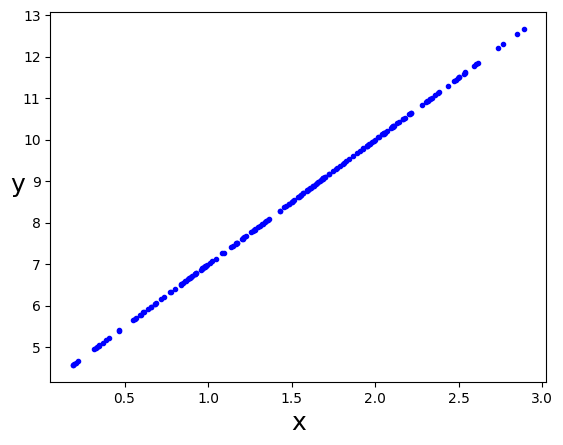

In [4]:
x = np.linspace(0.0, 2.0, num=200) + np.random.rand(200)
plt.plot(x, getTargetLinear(x, False), 'b.')
plt.xlabel("x", fontsize=18)
plt.ylabel("y", rotation=0, fontsize=18)

Text(0, 0.5, 'y')

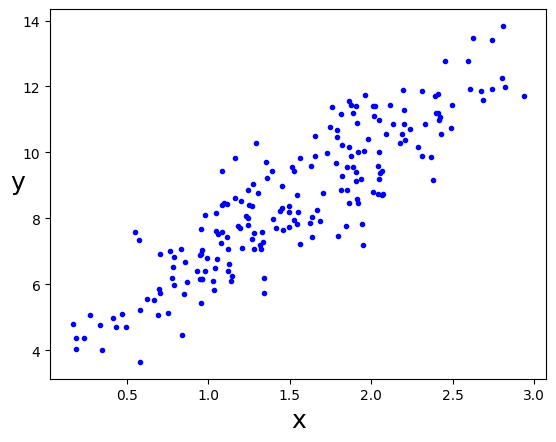

In [5]:
# estos valores son mas reales, con ruido.
x = np.linspace(0.0, 2.0, num=200) + np.random.rand(200)
plt.plot(x, getTargetLinear(x, True), 'b.')
plt.xlabel("x", fontsize=18)
plt.ylabel("y", rotation=0, fontsize=18)

Text(0, 0.5, 'y')

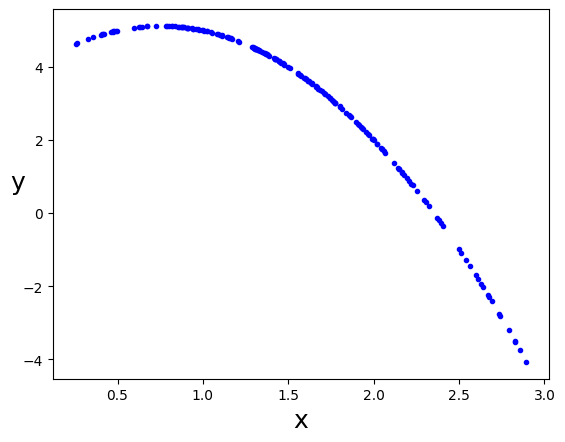

In [6]:
x = np.linspace(0.0, 2.0, num=200) + np.random.rand(200)
plt.plot(x, getTargetCuadratic(x, False), 'b.')
plt.xlabel("x", fontsize=18)
plt.ylabel("y", rotation=0, fontsize=18)

Text(0, 0.5, 'y')

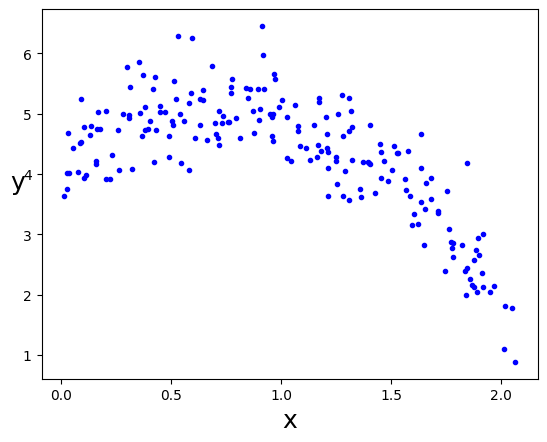

In [7]:
# asi seria la ecuacion cuadratica con ruido
x = np.linspace(0.0, 2.0, num=200) + np.random.uniform(low=-0.1, high=0.1, size=(200,))
plt.plot(x, getTargetCuadratic(x, True), 'b.')
plt.xlabel("x", fontsize=18)
plt.ylabel("y", rotation=0, fontsize=18)

## Gradient Descent

Una de las preguntas que aparecen al momento de entrenar estos modelos es poder definir hacia dónde nos conviene mover nuestros pesos para que el modelo vaya aproximandose a una mejor solución. Tal como vimos en clases, la dirección en la cual nos queremos mover es aquella que minimice la función de pérdida que definimos, y para eso es necesario moverse en sentido contrario a la pendiente del modelo en ese punto, o como también se conoce en el sentido contrario al gradiente.

## Ecuación que queremos aproximar

Primero necesitamos conocer las ecuaciones que queremos aproximar. Como estamos trabajando con funciones simples y queremos ver el impacto que tiene la actualización de los parámetros del modelo, definimos las dos funciones mostradas anteriormente. Con estas ecuaciones podemos definir dos modelos sencillos que nos ayudarán a aproximarlas utilizando solo los datos de entrenamiento.

Para el caso de la ecuación lineal definimos nuestro modelo como:

> $Y = 4 + 3 \cdot x$ \
> $\hat{Y} = h(\theta,x) = \theta_0 + \theta_1 \cdot x$

Para el caso de nuestra función cuadrática definimos nuestro modelo como:

> $Y = 4 + 3 \cdot x -2 \cdot x^2$ \
> $\hat{Y} = h(\theta,x) = \theta_0 + \theta_1 \cdot x + \theta_2 \cdot x^2$

Donde los valores $\theta_i$ son los parámetros que queremos aprender. Esto quiere decir, que estos son los valores que vamos a ir modificando en cada iteración del algoritmo para acercarnos a una buena aproximación de la función real.

## Función de pérdida

Lo segundo que necesitamos es una función de pérdida. Al ser un problema de regresión, debemos utilizar una función de pérdida que nos entregue la diferencia entre el valor esperado $Y$ y la predicción $\hat{Y}$. En esta oportunidad vamos a utilizar la función: *Mean Squared Error*, que tal como dice su nombre, calcula el error como la diferencia entre la predicción y el valor real, al cuadrado.

> $L(\theta) = \frac{1}{2m} \sum_{i=1}^m (h(\theta,x_i) - y_i)^2$

La función anterior, a pesar de ser muy simple, es muy utilizada en problemas de regresión, ya que nos dice claramente que tan lejos estamos de la solución real.





In [8]:
def  cal_loss(theta, X, y):
    '''
    Esta función es la encargada de calcular el costo de las predicciones hechas por la
    función con parametros theta
    '''

    m = len(y)

    # aqui se realizan las predicciones
    # multiplicacion matricial de X por tetha
    predictions = X.dot(theta) # sale un vector
    cost = (1/2*m) * np.sum(np.square(predictions - y))
    return cost

## Gradiente

Lo único que nos falta es saber como calcular la dirección en la que tenemos que mover los pesos de nuestro modelo dado el error que nuestra función de pérdida nos entrega. Para esto, debemos derivar nuestra función de pérdida con respecto a cada parámetro que tenemos, resultando:

> $\frac{\partial L(\theta)}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^m (h(\theta,x_i) - y_i)\cdot X_i^j$

Dado lo anterior, la actualización de cada valor de $\theta$ de nuestro modelo quedaría de la siguiente forma:

> $\theta_j = \theta_j - \alpha \cdot \frac{1}{m} \sum_{i=1}^m (h(\theta,x_i) - y_i)\cdot X_i^j$,

ya que queremos movernos en sentido contrario al gradiente, multiplicado por $\alpha$ que es el valor de nuestro *learning rate*. Donde $j$ es el número de características de nuestras observaciones $X$.

In [9]:
def gradient_descent(X, y, theta, learning_rate=0.01, iterations=100): # 100 epocas
    '''
    X             = Observaciones
    y             = Valores reales de cada observación
    theta         = Parámetros de nuestro modelo
    learning_rate = Tasa de aprendizaje
    iterations    = número de iteraciones

    Se retorna el valor final de los parámetros y el historial de la función de costo
    '''
    m = len(y)
    # primero queremos calcular como evoluciona la perdida - la historia
    cost_history = np.zeros(iterations)
    # tambien queremos ver como evoluciona theta - los pesos del modelo
    theta_history = np.zeros((iterations,theta.size))
    for it in range(iterations): # como es GD, es un gran batch con todos los datos - 1 epoca
        # la prediccion va a ser el producto punto
        # es una función lineal
        prediction = np.dot(X, theta)
        # actualizamos los valores de theha
        theta = theta - learning_rate * (1/m) * (X.T.dot((prediction - y)))

        theta_history[it,:] = theta.T
        cost_history[it]  = cal_loss(theta, X, y)

    return theta, cost_history, theta_history

## Métricas
Si tenemos un modelo que se demora días o semanas en entrenar, nos gustaría saber como va el entrenamiento antes de que terminara, principalmente para poder detectar problemas de manera más rápida, sin tener que esperar todo el proceso de entrenamiento.

Debido a lo anterior, es muy importante ir midiendo como evoluciona el valor de nuestra función de pérdida durante el entrenamiento, ya que es el valor que nos indica si efectivamente el modelo está entrenando o no. Durante el entrenamiento, esperamos que el valor de nuestra función de pérdida (calculado sobre los mismos datos de entrenamiento) baje, si esta no baja constantemente puede existir un problema.

Diferentes posibles problemas:

1.  El valor nunca baja: El modelo tiene un problema grave, ya que no se está actualizando correctamente los pesos.
2.  El valor baja pero hasta un valor alto o sube: Puede que el *learning rate* esté muy alto.
3.  El valor baja muy lento: Puede que el *learning rate* está muy bajo.


La siguiente función nos ayuda a visualizar como va el entrenamiento, graficando cómo evoluciona la función que queremos aproximar en comparación con la función real. Esto se puede hacer únicamente porque queremos aproximar funciones simples con baja dimensionalidad. En caso de modelos más complejos basta con ir analizando como evoluciona el valor de la función de pérdida en cada época.



In [10]:
def plot_GD(x, y, theta_size, X_b, n_iter, lr, ax, ax1=None):
     """
     n_iter = no of iterations
     lr = Learning Rate
     ax = Axis to plot the Gradient Descent
     ax1 = Axis to plot cost_history vs Iterations plot

     """
     _ = ax.plot(x,y,'b.')
     theta = np.random.randn(theta_size, 1)

     tr = 0.1
     cost_history = np.zeros(n_iter)
     for i in range(n_iter):
        pred_prev = X_b.dot(theta)
        theta, h, _ = gradient_descent(X_b, y, theta, lr, 1)
        pred = X_b.dot(theta)

        cost_history[i] = h[0]

        if ((i % 25 == 0)):
            _ = ax.plot(x, pred, 'r-', alpha=tr)
            if tr < 0.8:
                tr = tr + 0.2
     if not ax1 == None:
        _ = ax1.plot(range(n_iter), cost_history, 'b.')

## Función Lineal



Theta0:	3.702,
Theta1:	3.249
Final cost/MSE:  1783.450


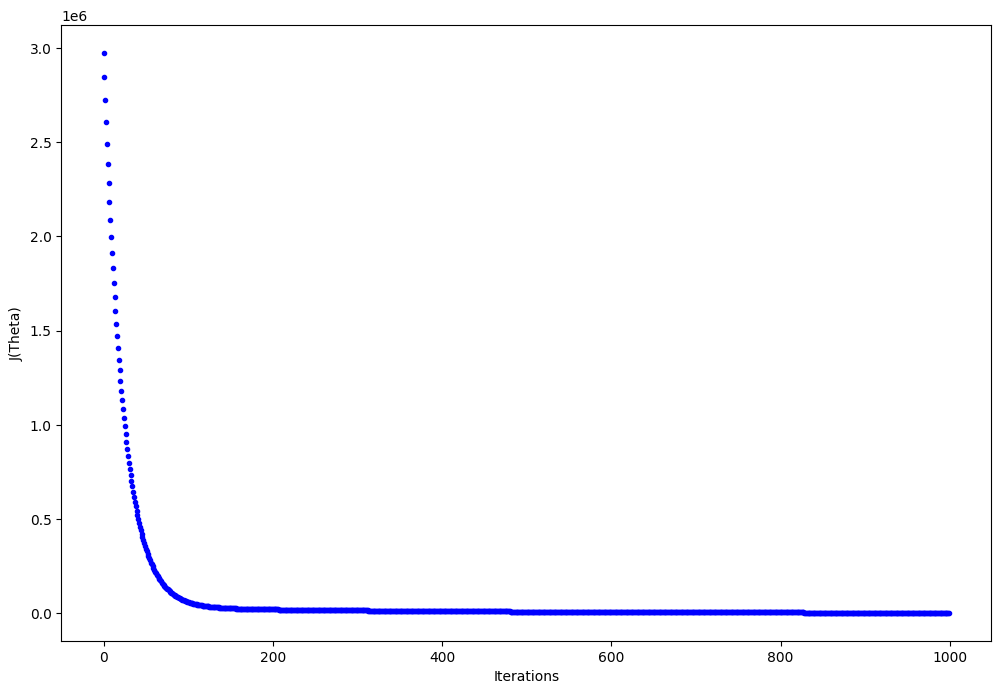

In [11]:
# y = 4 + 3 * x
# Primero debemos generar los datos que vamos a utilizar para entrenar nuestro modelo
x = np.random.uniform(low=0, high=2.0, size=(400,1))
y = getTargetLinear(x, False) # no tiene ruido

# Hiper-parámetros
lr = 0.01
n_iter = 1000

# En el caso lineal, nuestro modelo tiene solo 2 parámetros theta
theta = np.random.randn(2,1) # iniciar mis pesos
theta_size = 2

# Actualizamos las características de nuestro X
# Esto para tener un calculo matricial que nos permita hacer el producto punto
X_b = np.c_[np.ones((len(x), 1)), x]
theta, cost_history, theta_history = gradient_descent(X_b, y, theta, lr, n_iter)

print('Theta0:\t{:0.3f},\nTheta1:\t{:0.3f}'.format(theta[0][0], theta[1][0]))
print('Final cost/MSE:  {:0.3f}'.format(cost_history[-1]))

fig, ax = plt.subplots(figsize=(12, 8))

ax.set_ylabel('J(Theta)')
ax.set_xlabel('Iterations')
_ = ax.plot(range(n_iter), cost_history, 'b.')

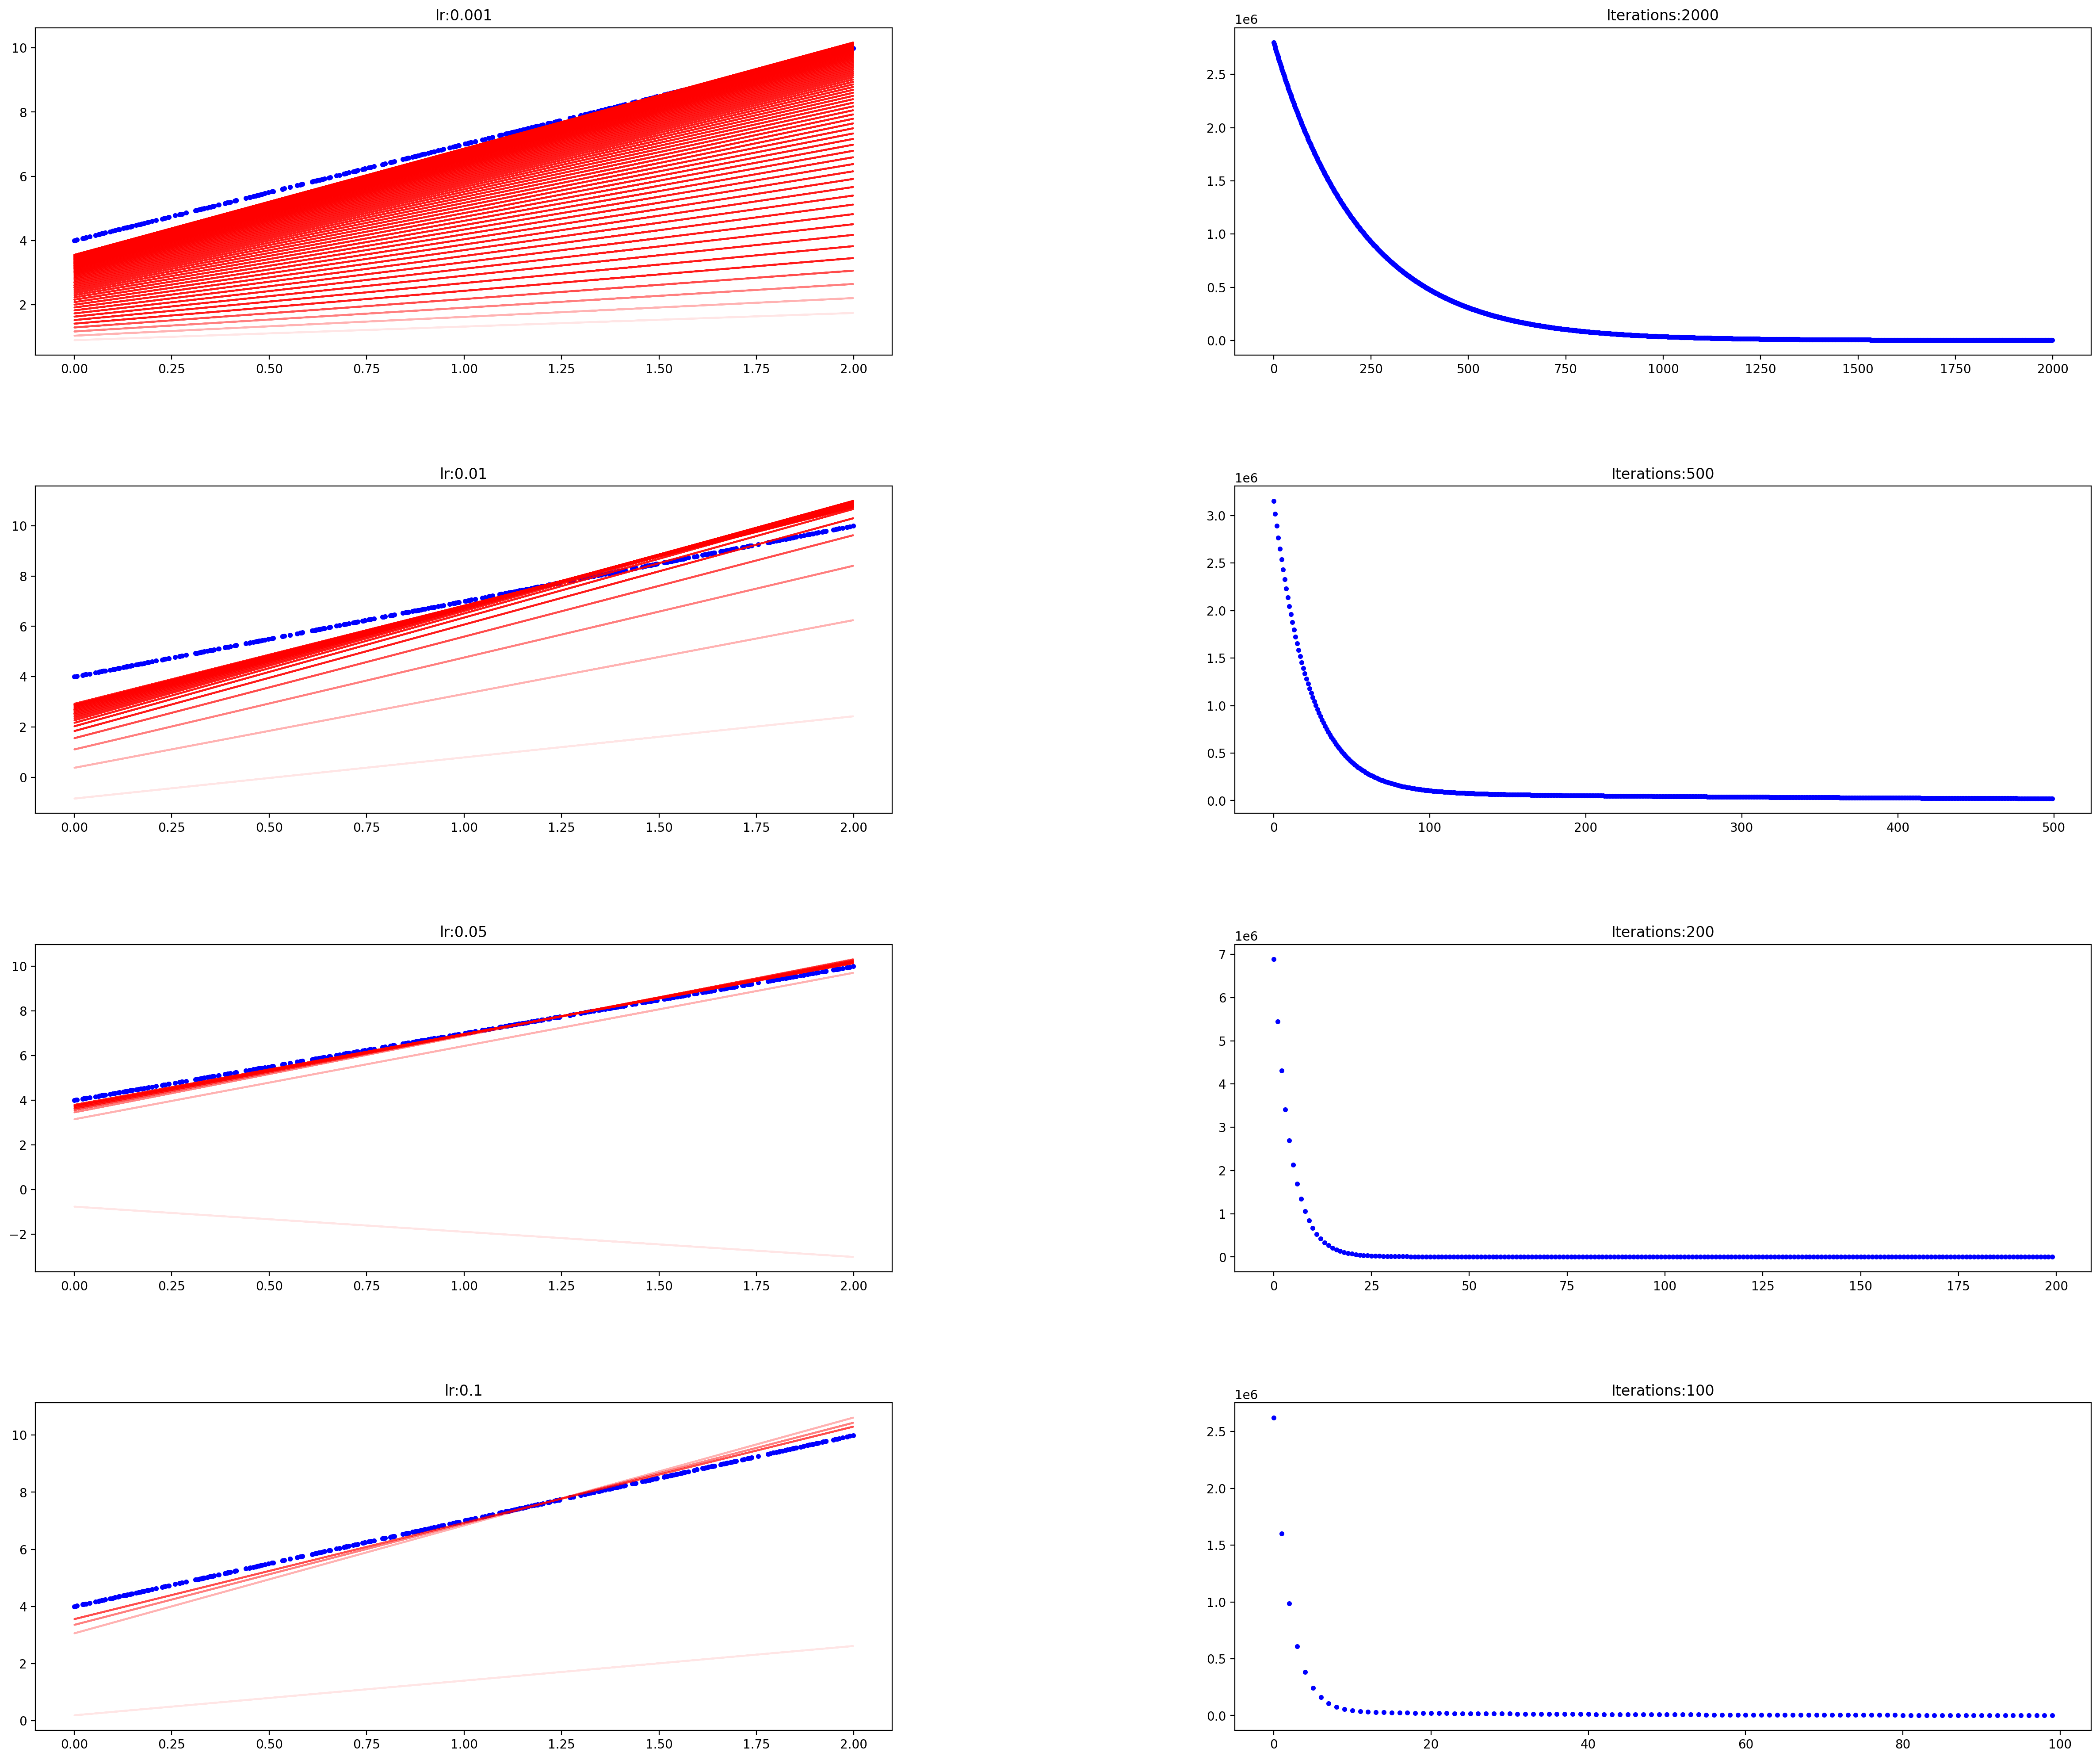

In [12]:
fig = plt.figure(figsize=(30, 25), dpi=200)
fig.subplots_adjust(hspace=0.4, wspace=0.4)

# provemos con varios valores de lr y varias iteraciones
# el valor de lr esta asociado a que tan rapido aprendemos
it_lr = [(2000, 0.001), (500, 0.01), (200, 0.05), (100, 0.1)] # lista de tuplas
count = 0
# Se gráfica cada combinación de número de iteraciones con el learning rate correspondiente
for n_iter, lr in it_lr:
    count += 1

    ax = fig.add_subplot(4, 2, count)
    count += 1

    ax1 = fig.add_subplot(4, 2, count)

    ax.set_title("lr:{}".format(lr))
    ax1.set_title("Iterations:{}".format(n_iter))
    plot_GD(x, y, theta_size, X_b, n_iter, lr, ax, ax1)

## Función Cuadrática

Theta0:	4.649,
Theta1:	0.996
Theta2:	-1.006
Final cost/MSE:  7225.114


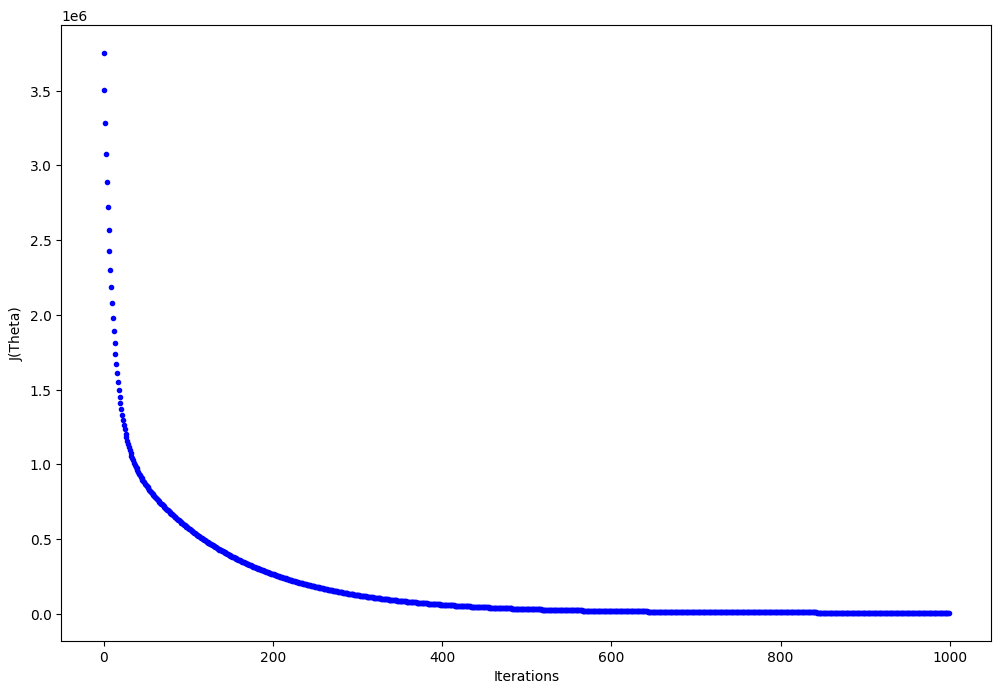

In [13]:
# y = 4 + 3 * x - 2 * x**2
# Inicialización de datos
x = np.random.uniform(low=0, high=2.0, size=(400,1))
y = getTargetCuadratic(x, False)

# Hiper-parámetros
lr = 0.01
n_iter = 1000

# Inicialización de los pesos de nuestro modelo
theta = np.random.randn(3, 1)
theta_size = 3

X_b = np.c_[np.ones((len(x),1)), x, x**2]
theta, cost_history, theta_history = gradient_descent(X_b, y, theta, lr, n_iter)

print('Theta0:\t{:0.3f},\nTheta1:\t{:0.3f}\nTheta2:\t{:0.3f}'.format(theta[0][0], theta[1][0], theta[2][0]))
print('Final cost/MSE:  {:0.3f}'.format(cost_history[-1]))

fig, ax = plt.subplots(figsize=(12, 8))

ax.set_ylabel('J(Theta)')
ax.set_xlabel('Iterations')
_ = ax.plot(range(n_iter), cost_history, 'b.')

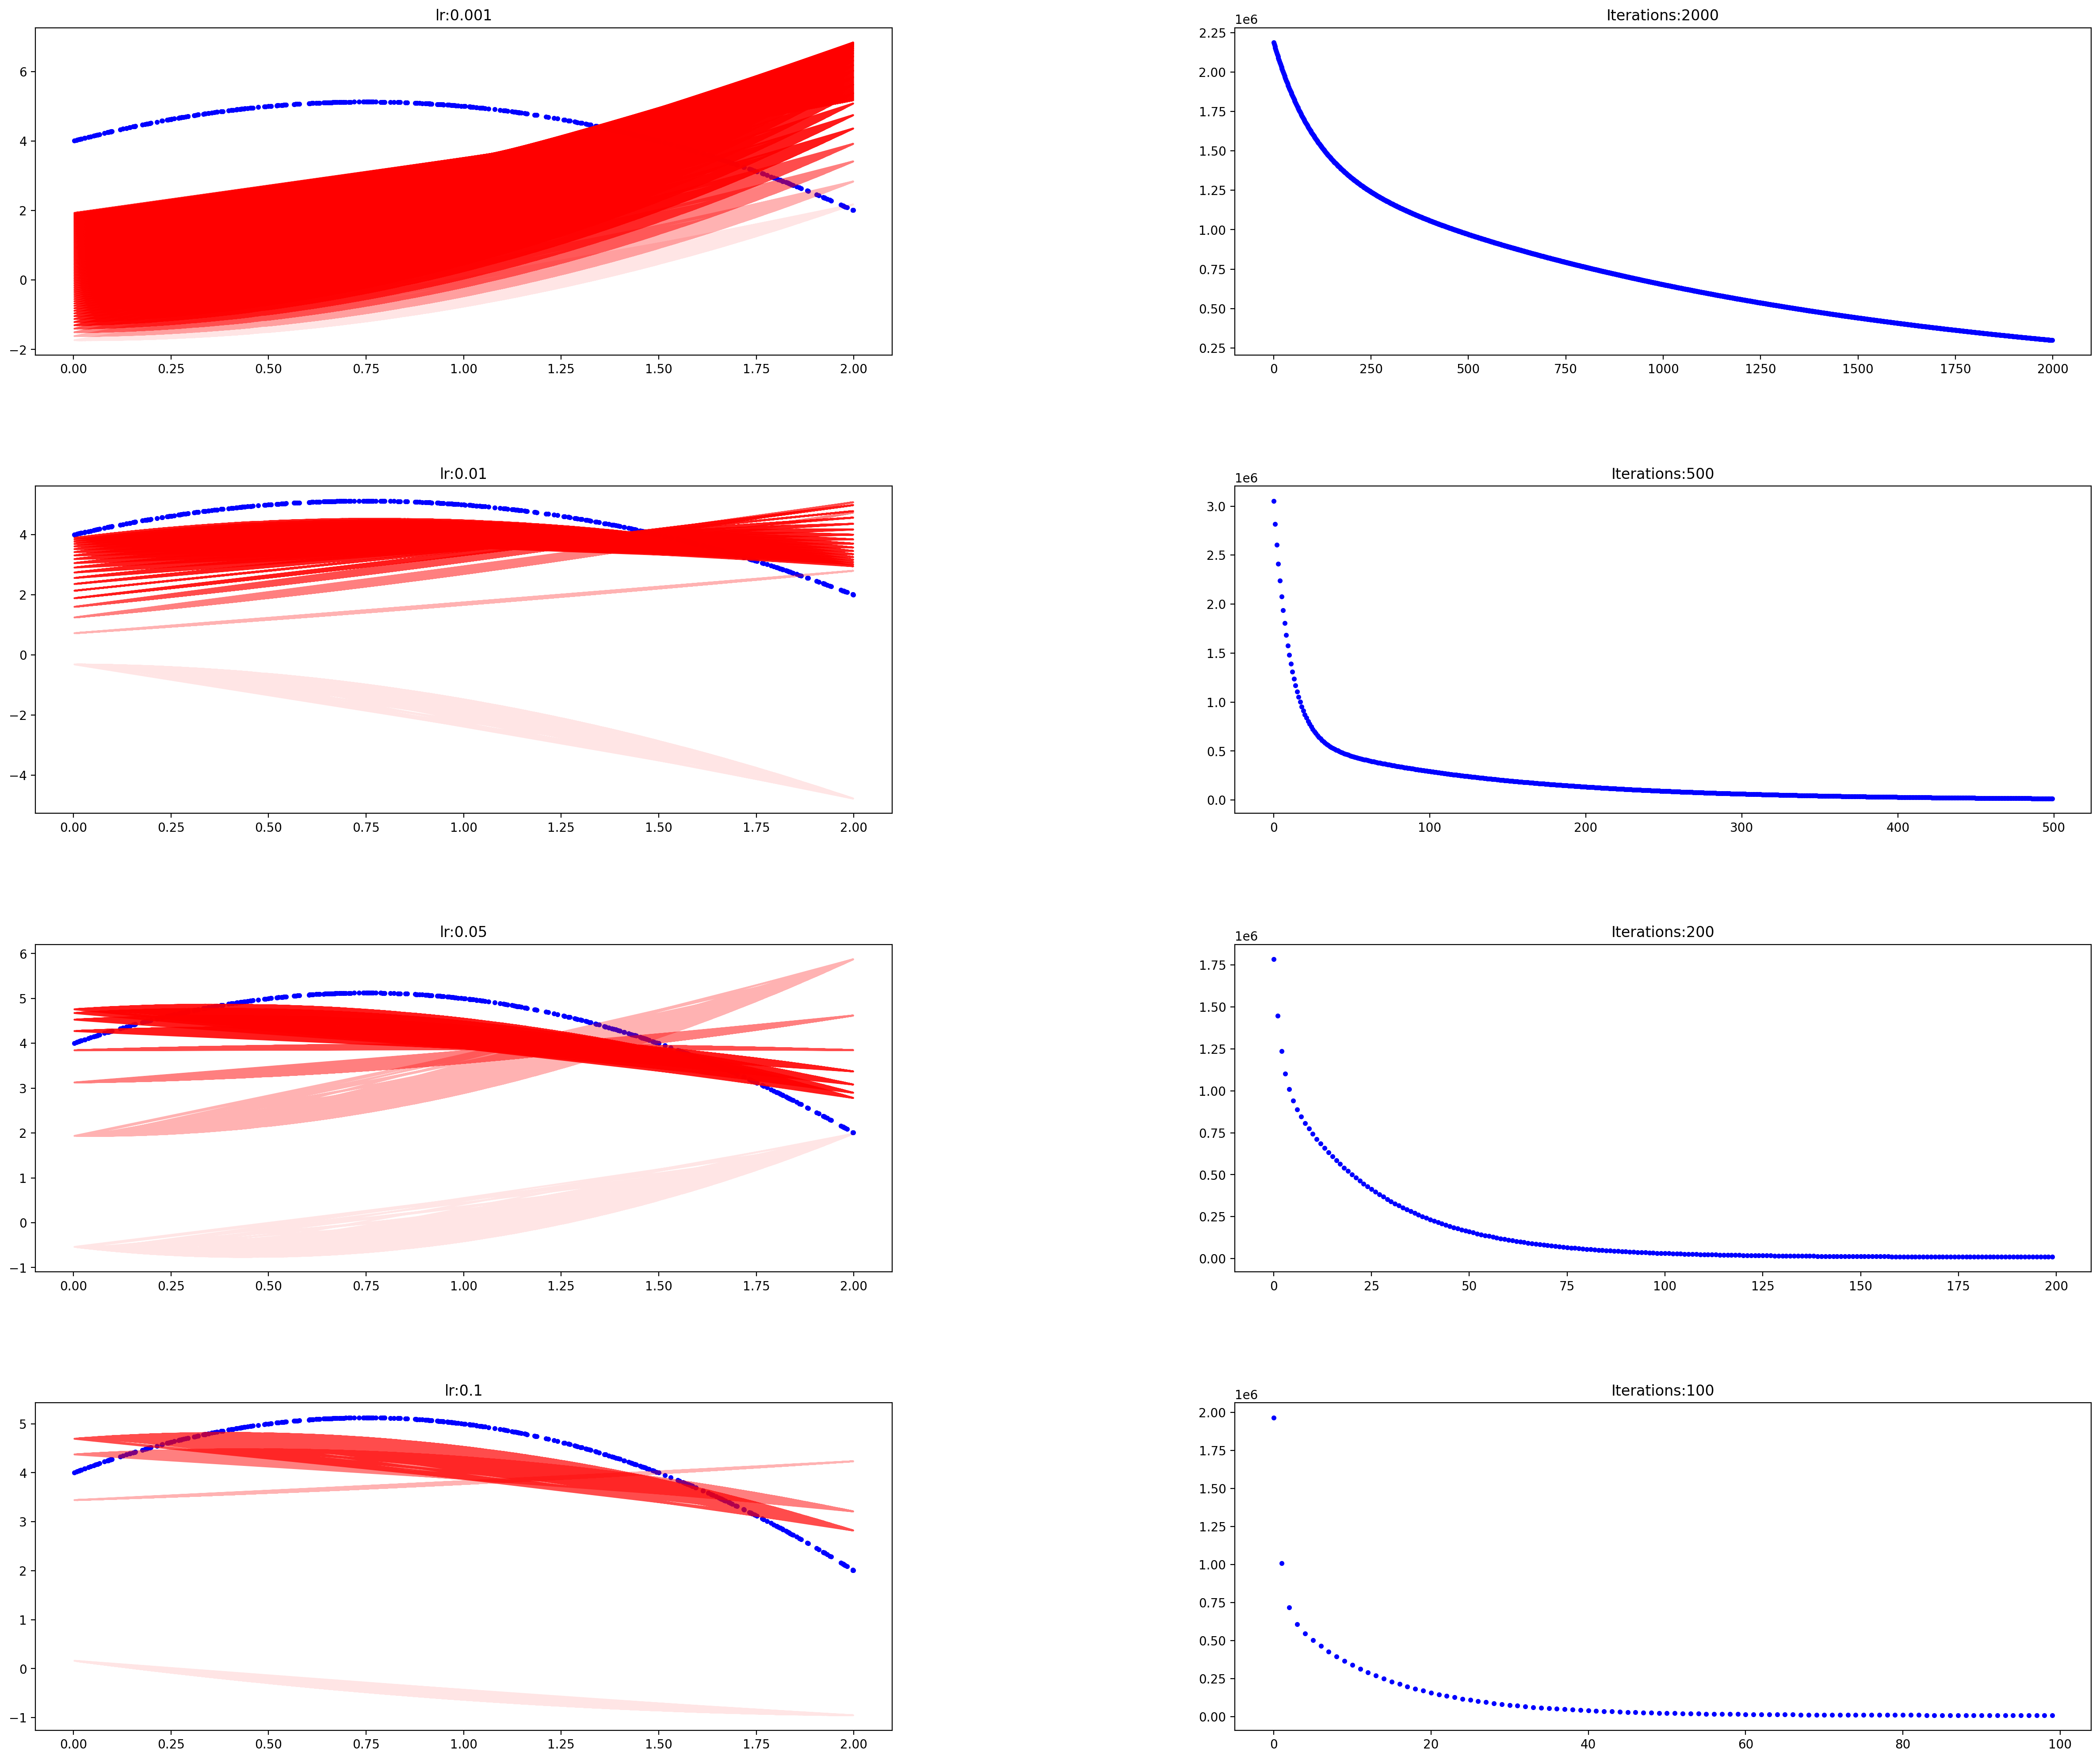

In [14]:
fig = plt.figure(figsize=(30, 25), dpi=200)
fig.subplots_adjust(hspace=0.4, wspace=0.4)

it_lr = [(2000, 0.001), (500, 0.01), (200, 0.05), (100, 0.1)]
count = 0
for n_iter, lr in it_lr:
    count += 1

    ax = fig.add_subplot(4, 2, count)
    count += 1

    ax1 = fig.add_subplot(4, 2, count)

    ax.set_title("lr:{}".format(lr))
    ax1.set_title("Iterations:{}".format(n_iter))
    plot_GD(x, y, theta_size, X_b, n_iter, lr, ax, ax1)

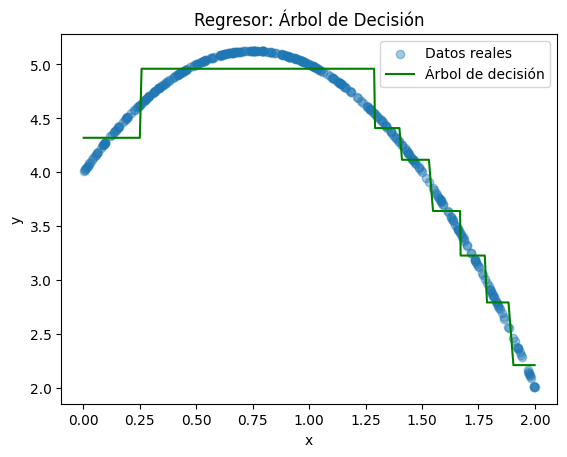

In [15]:
#@title un modelo de ML
from sklearn.tree import DecisionTreeRegressor

# Entrenamiento
model = DecisionTreeRegressor(max_depth=3)
model.fit(x, y)

# Predicción ordenada para graficar
x_sorted = np.sort(x, axis=0)
y_pred = model.predict(x_sorted)

# Visualización
plt.scatter(x, y, alpha=0.4, label='Datos reales')
plt.plot(x_sorted, y_pred, color='g', label='Árbol de decisión')
plt.legend()
plt.title('Regresor: Árbol de Decisión')
plt.xlabel('x')
plt.ylabel('y')
plt.show()


🔹 Learning rate = 0.0001 -> Final loss: 0.1201
🔹 Learning rate =  0.001 -> Final loss: 0.1115
🔹 Learning rate =   0.01 -> Final loss: 0.1104
🔹 Learning rate =    0.1 -> Final loss: 0.1190


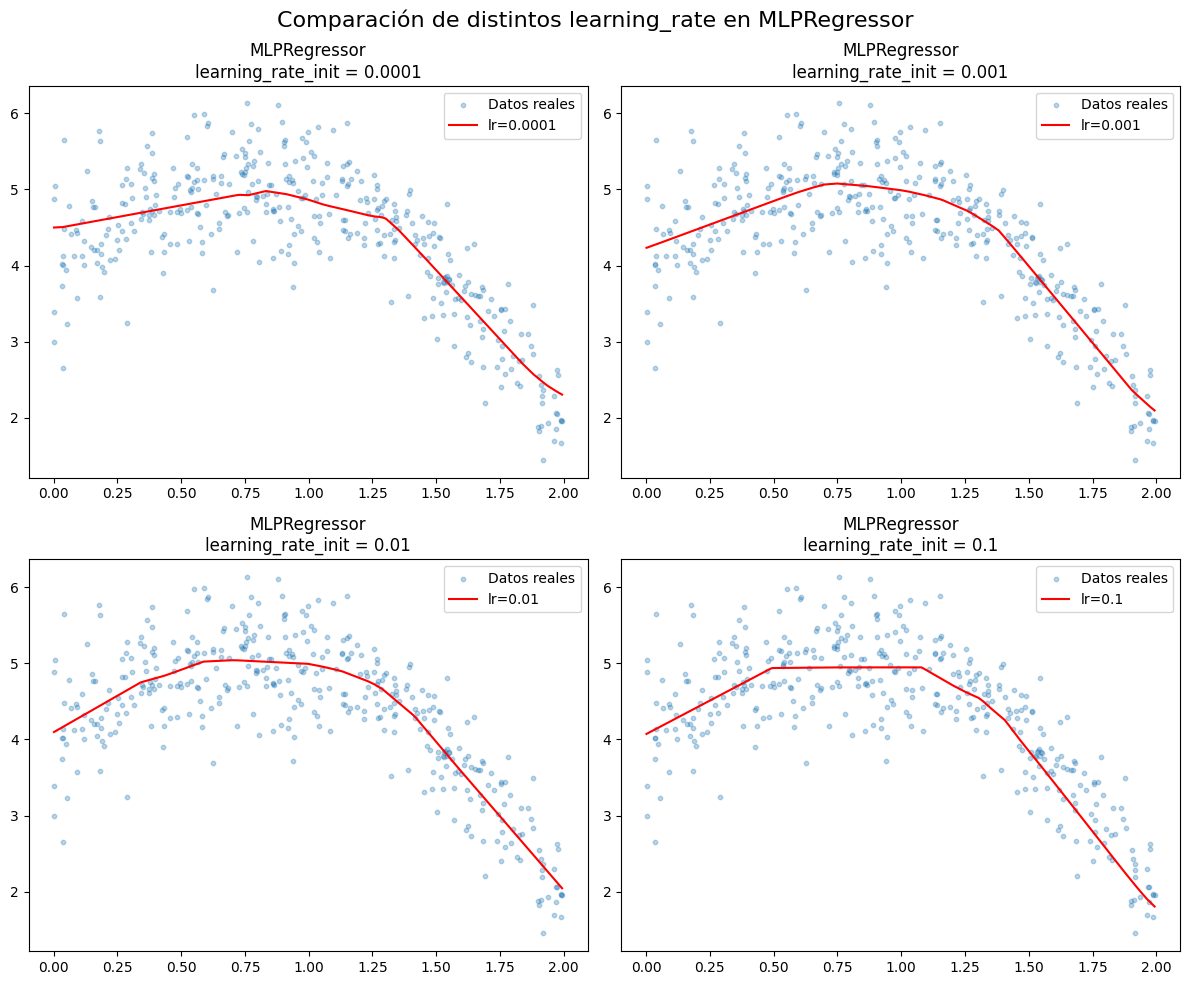

In [16]:
#@title un modelo de MLPRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

def getTargetCuadratic(x, noise=False):
    y = 4 + 3*x - 2*x**2
    if noise:
        y += np.random.normal(0, 0.5, size=y.shape)
    return y

# Datos
x = np.random.uniform(0, 2.0, size=(400, 1))
y = getTargetCuadratic(x, noise=True).ravel()

# Escalado
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
x_sorted = np.sort(x, axis=0)
x_sorted_scaled = scaler.transform(x_sorted)

# Learning rates a probar
learning_rates = [0.0001, 0.001, 0.01, 0.1]

# Plot
plt.figure(figsize=(12, 10))

for i, lr in enumerate(learning_rates):
    model = MLPRegressor(hidden_layer_sizes=(20,100),
                         learning_rate_init=lr,
                         max_iter=2000,
                         random_state=42)
    model.fit(x_scaled, y)
    y_pred = model.predict(x_sorted_scaled)

    # Mostrar gráfica
    plt.subplot(2, 2, i + 1)
    plt.scatter(x, y, s=10, alpha=0.3, label="Datos reales")
    plt.plot(x_sorted, y_pred, 'r', label=f'lr={lr}')
    plt.title(f'MLPRegressor\nlearning_rate_init = {lr}')
    plt.legend()

    # Imprimir pérdida final
    print(f"🔹 Learning rate = {lr:>6} -> Final loss: {model.loss_:.4f}")

plt.suptitle("Comparación de distintos learning_rate en MLPRegressor", fontsize=16)
plt.tight_layout()
plt.show()


# Actividad 2 - Stochastic Gradient Descent
Ahora que entendemos como funciona un proceso básico de optimización basado en actualización del gradiente, podemos explorar problemas más complejos.

En esta actividad entrenaremos un modelo de aprendizaje profundo para predecir etiquetas de imágenes. En esta ocasión utilizaremos el dataset `CIFAR10`, que consiste en pequeñas imágenes de 10 clases diferentes.

Tal como vimos en clases, experimentamos con lo siguiente:

* Actualización de gradiente basada en `momentum` y `nesterov`.
* Alternativas a `SGD` como `Adagrad` y `Adam`.
* Learning Rate.

Para hacer el proceso más simple, utilizaremos `PyTorch`. Como ustedes ya deben saber, es un framework the python que nos permite trabajar con métodos de machine learning y que nos simplifica pasos como: la creación de modelos, obtención de dataset, cálculo del gradiente, etc.

### Datos

Lo maś importante para trabajar con estos modelos son los datos. Para esto, `PyTorch` tiene `torchvision.dataset` donde tiene una gran variedad de dataset y funciones que nos ayudan a trabajar con ellos.

En el siguiente código, bajamos nuestro dataset y creamos nuestro dataloaders.


In [17]:
import torch
import torchvision
import torchvision.transforms as transforms

transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)

# el dataloader divide automaticamente en batches, y le damos el tamano
trainloader = torch.utils.data.DataLoader(trainset, batch_size=512,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=512,
                                         shuffle=False, num_workers=2) # hacer mas solida la validacion

# Función que nos permite utilizar GPU durante el entrenamiento (si es que esta habilitada)
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")

100%|██████████| 170M/170M [00:11<00:00, 14.8MB/s]


Veamos algunas imágenes de ejemplo

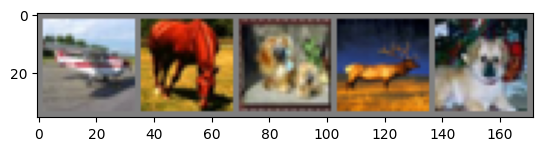

LABELS: 
plane horse   dog  deer   dog


In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Las 10 etiquetas que utiliza este dataset
classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# Obtenemos algunas imágenes de ejemplo
loader = torch.utils.data.DataLoader(trainset, batch_size=5,
                                     shuffle=True, num_workers=2)
dataiter = iter(loader)
images, labels = next(dataiter)

# Mostramos las imágenes
imshow(torchvision.utils.make_grid(images))

# Imprimimos las etiquetas
print('LABELS: ')
print(' '.join('%5s' % classes[labels[j]] for j in range(len(labels))))

## Modelo

El modelo que vamos a utilizar es bastante pequeño. Contiene dos capas convolucionales y luego dos capas lineales, encargadas de hacer la clasificación.

In [19]:
import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        # primera capa convolucional
        self.conv1 = nn.Conv2d(3, 6, 5)
        # un proceso de max pooling entre capas
        self.pool = nn.MaxPool2d(2, 2)
        # una segunda capa convolucional
        self.conv2 = nn.Conv2d(6, 16, 5)
        # dos capas lineales
        # la primer transforma la salida de la conv a un vector de 120
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        # la segunda transforma a un vector de 10, una capa para cada label a clasificar
        self.fc2 = nn.Linear(120, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        # View es similar a flatten, se realiza un reshape de la forma (batch_size, dimension del vector)
        # 16 son la cantidad de canales del la capa convolucional de la capa anterior
        # 5 * 5 es el valor del alto por ancho del mapa de activación
        # Con este view, el vector x queda con dimension (batch_size, 16*5*5)
        x = x.view(-1, 16 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


net = Net().to(device)


In [20]:
import numpy as np

# Procedimiento de entrenamiento del modelo
def train(net, trainloader, optimizer, criterion, lr, epochs=60, scheduler=None): # vamos a partir sin scheduler
    total_loss = []
    net.train()
    for epoch in range(epochs):  # loops sobre el dataset de entrenamiento multiples veces

        running_loss = []
        for i, data in enumerate(trainloader, 0): # aqui empiezan las iteraciones

            # obtener los inputs en forma de lista de [inputs, labels]
            inputs, labels = data
            # cada vez que recibimos un batch, lo enviamos a GPU
            inputs = inputs.to(device)
            labels = labels.to(device)

            # forward + backward + optimizacion
            outputs = net(inputs) # y = f(x)
            # aqui se calcula la funcion de perdida entre output y ground truth
            loss = criterion(outputs, labels)
            # aqui es donde actualizamos los gradientes del modelo
            # a cada uno de los pesos asosicados, les encuentra la pendiente y luego el gradiente
            loss.backward()
            # toma los gradientes de los pesos, y los optimiza
            optimizer.step()

            # inicializa gradientes en zero
            optimizer.zero_grad() # si no reiniciamos, se van a sumar y acumular lo gradientes!!

            # guardar estadisticas
            running_loss.append(loss.item())

        total_loss.append(np.mean(running_loss)) # mean([0.4,0.9,5,20,0.4])
        if scheduler:
            scheduler.step(np.mean(running_loss))

    print('Finished Training of {}'.format(lr))
    return total_loss

# Procedimiento de prueba
# Similar al entrenamiento, la diferencia es que no se realiza actualización de los pesos
def test(testloader, net):
    correct = 0
    total = 0
    net.eval()
    with torch.no_grad():
        for data in testloader: # sin epoca porque solo pasamos 1 vez por los datos
            images, labels = data
            images = images.to(device)
            labels = labels.to(device)
            outputs = net(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print('Accuracy of the network on the 10000 test images: %d %%' % (
        100 * correct / total))


## Actividad Practica 1

1.   Mire la documentación de PyTorch, específicamente la función SGD en https://pytorch.org/docs/stable/optim.html, y comente los diferentes parámetros que tiene la función. Aplique los conocimientos vistos en clases.

Respuesta:

**Explicación de los parámetros del optimizador SGD (Stochastic Gradient Descent):**

*   **params (iterable)**: Es un iterable de `torch.Tensor` que contiene todos los parámetros que queremos optimizar. En nuestro caso, estos son los pesos y biases de todas las capas de la red neuronal. Los obtenemos llamando `net.parameters()`. Básicamente, le estamos diciendo al optimizador: "estos son los valores que debes actualizar en cada iteración".

*   **lr (float)**: Learning rate o tasa de aprendizaje. Es un valor entre 0 y 1 que determina qué tan grandes son los pasos que damos en la dirección del gradiente. En SGD, el learning rate es constante durante todo el entrenamiento (a menos que usemos un scheduler). Un valor muy alto puede hacer que el modelo "salte" el mínimo óptimo, mientras que un valor muy bajo hará que el entrenamiento sea muy lento. Por ejemplo, `lr=0.01` significa que en cada paso actualizamos los pesos moviéndonos el 1% en la dirección opuesta al gradiente.

*   **momentum (float, opcional, default=0)**: Es un valor entre 0 y 1 que ayuda a acelerar el SGD en la dirección correcta y reducir las oscilaciones. Funciona como una "inercia" que acumula las actualizaciones previas. Con momentum=0.9, el 90% del paso actual depende de la velocidad acumulada de pasos anteriores, y solo el 10% depende del gradiente actual. Esto ayuda a escapar de mínimos locales y acelera la convergencia.

*   **weight_decay (float, opcional, default=0)**: También conocido como regularización L2. Es un término que penaliza pesos muy grandes, ayudando a prevenir el overfitting. Si usamos `weight_decay=0.0001`, estamos agregando un término de penalización a la función de pérdida proporcional al cuadrado de los pesos. Esto fuerza a la red a mantener pesos más pequeños, lo que generalmente mejora la generalización.

*   **dampening (float, opcional, default=0)**: Es un factor que reduce el efecto del momentum. Específicamente, reduce la contribución del gradiente actual cuando se calcula la velocidad. No es tan común ajustar este parámetro en la práctica.

*   **nesterov (bool, opcional, default=False)**: Si es True, usa Nesterov Momentum, que es una variación mejorada del momentum estándar. La idea es que en lugar de calcular el gradiente en la posición actual, lo calculamos en una posición "anticipada" considerando el momentum. Esto permite hacer correcciones más inteligentes y suele converger más rápido. Solo se puede usar si momentum > 0.

**En resumen:** El optimizador SGD toma los parámetros de nuestra red y los actualiza iterativamente usando el gradiente de la función de pérdida. Los hiperparámetros (lr, momentum, etc.) controlan cómo se realiza esta actualización.



## Ajuste de los Hiper-Parámetros

Un punto importante para el entrenamiento correcto de modelos es la selección de hiper-parámetros. Tal como vimos en clases, existen varios algoritmos de optimización y cada uno de estos tiene diferentes hiper-parámetros que tenemos que ajustar.

Para ver el impacto que tiene utilizar diferentes hiper-parámetros vamos a utilizar al algoritmo SGD. Utilizando el mismo modelo con los mismos datos de entrenamiento y test, probaremos diferentes valores de:

* Learning Rate
* Momentum
* Nesterov

Probar con diferentes valores nos permite encontrar cual es el más indicado para realizar el entrenamiento completo posteriormente. Para probar se suele utilizar un subconjunto de los datos, cuando el set es muy grande, en nuestro caso no tenemos tantos por lo que no hay problema con hacer estas pruebas con todos los datos.

###   Learning Rate

Este valor determina qué tan grande o pequeños son los pasos que vamos a dar en dirección al gradiente. Un learning alto, significa que podemos dar pasos más grandes en dirección al óptimo, pero puede tener el problema de poca precisión. En cambio, un learning bajo, nos puede entregar la precisión para avanzar siempre hacia el óptimo pero puede demorarse mucho.



Finished Training of 0.0001
Accuracy of the network on the 10000 test images: 11 %
Finished Training of 0.001
Accuracy of the network on the 10000 test images: 40 %
Finished Training of 0.01
Accuracy of the network on the 10000 test images: 62 %
Finished Training of 0.1
Accuracy of the network on the 10000 test images: 59 %


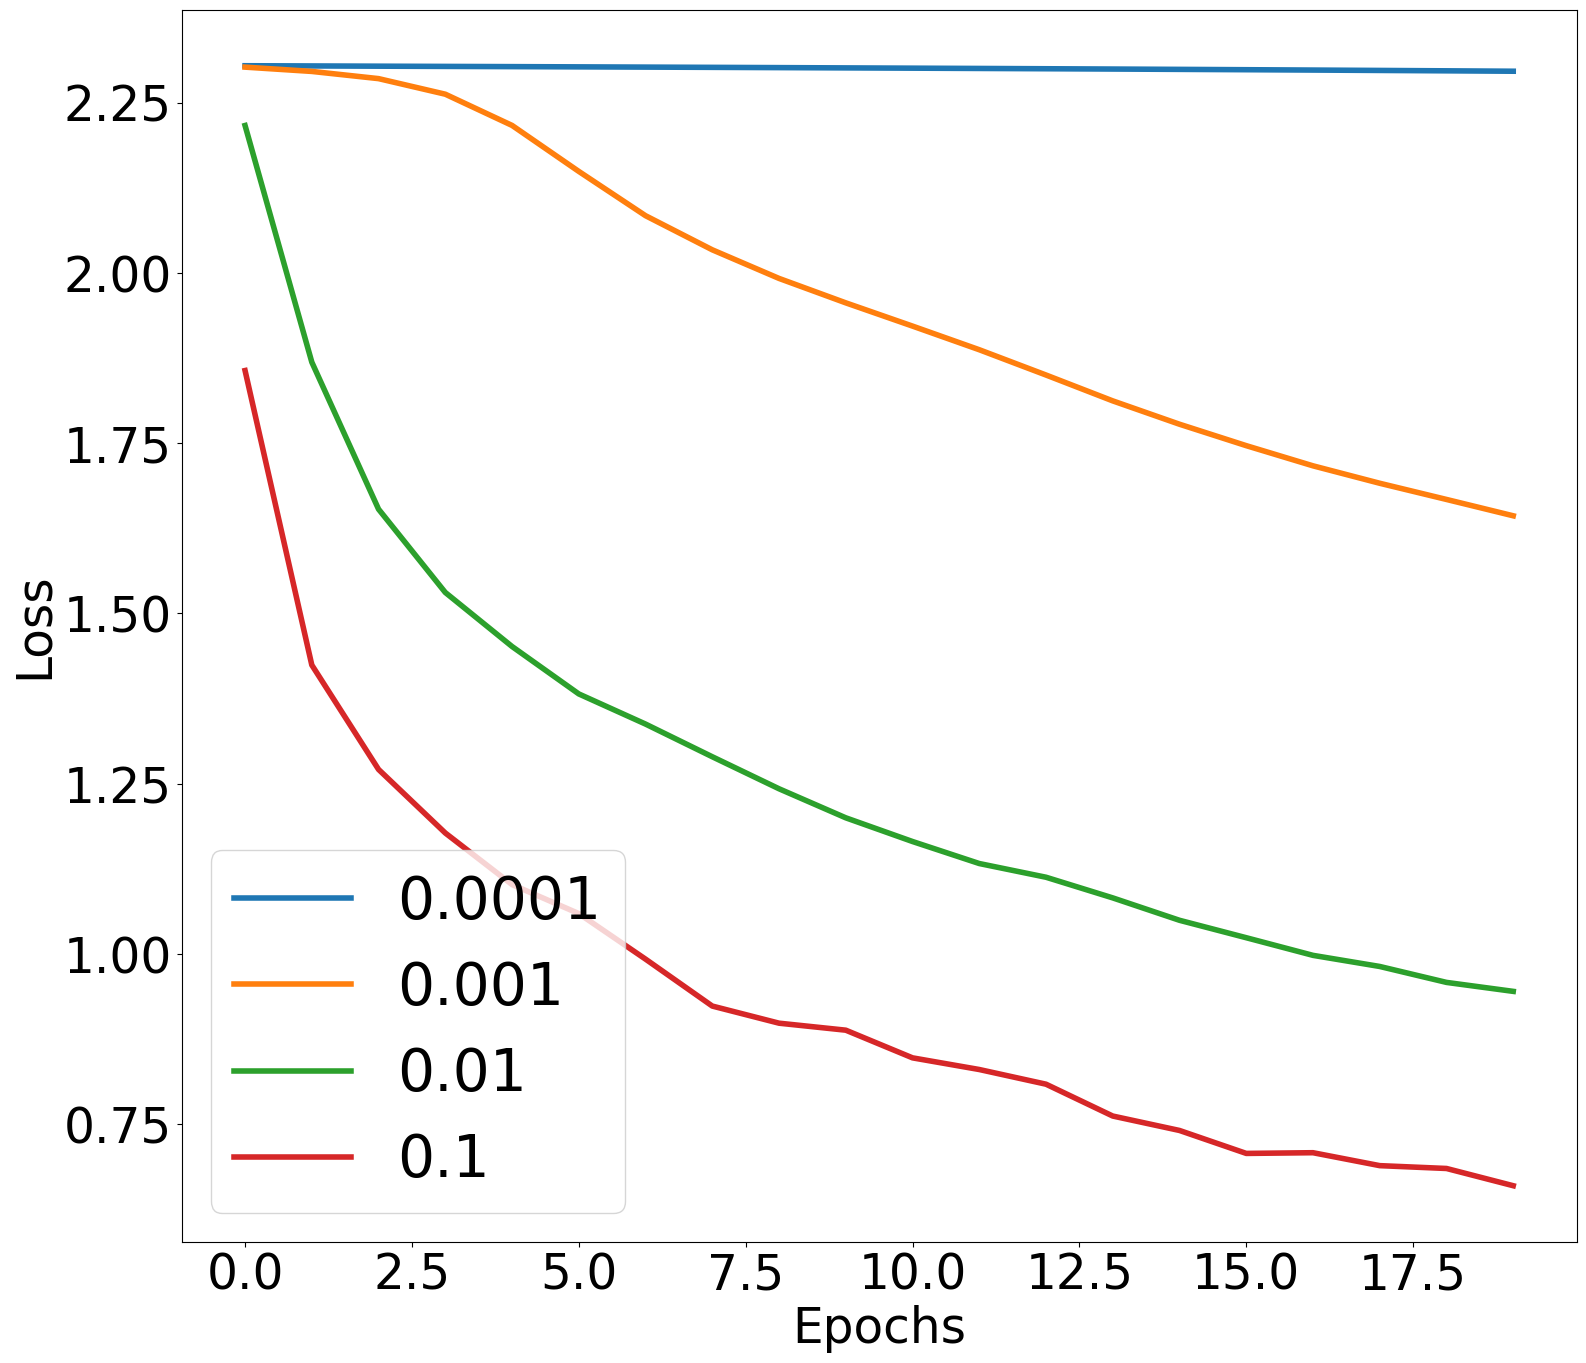

In [21]:
import torch.optim as optim
import matplotlib.pyplot as plt

criterion = nn.CrossEntropyLoss() # la funcion de perdida
epochs = 20

fig = plt.figure(figsize=(18, 16))

# Iteración sobre los diferentes valores de learning rate, manteniendo fijo el resto de los valores
for lr in [0.0001, 0.001, 0.01, 0.1]:   # de valores pequeños a grandes
    net = Net().to(device)
    optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9)  # utilizamos SGD al que le pasamos los parametros es decir los pesos, el lr y el momemntum
    loss = train(net, trainloader, optimizer, criterion, lr, epochs=epochs)
    test(testloader, net)

    plt.plot(loss, label=lr, linewidth=4)

plt.xlabel("Epochs", fontsize=35)
plt.xticks(fontsize=35)
plt.ylabel("Loss", fontsize=35)
plt.yticks(fontsize=35)
plt.legend(prop={'size': 42})
plt.show()

### Actividad Práctica 2


1.  Explique el gráfico obtenido en el bloque anterior (con diferentes valores de learning rate). ¿Por qué hay tanta diferencia entre los diferentes valores de learning rate?
2.  En el siguiente bloque de código, entrene el modelo con valores mayores de learning rate (1, 10, 100).
3.  Comente los resultados, explicando la diferencia de ambos gráficos (el anterior y el generado por uds.).



Finished Training of 1
Accuracy of the network on the 10000 test images: 10 %
Finished Training of 10
Accuracy of the network on the 10000 test images: 10 %
Finished Training of 100
Accuracy of the network on the 10000 test images: 10 %


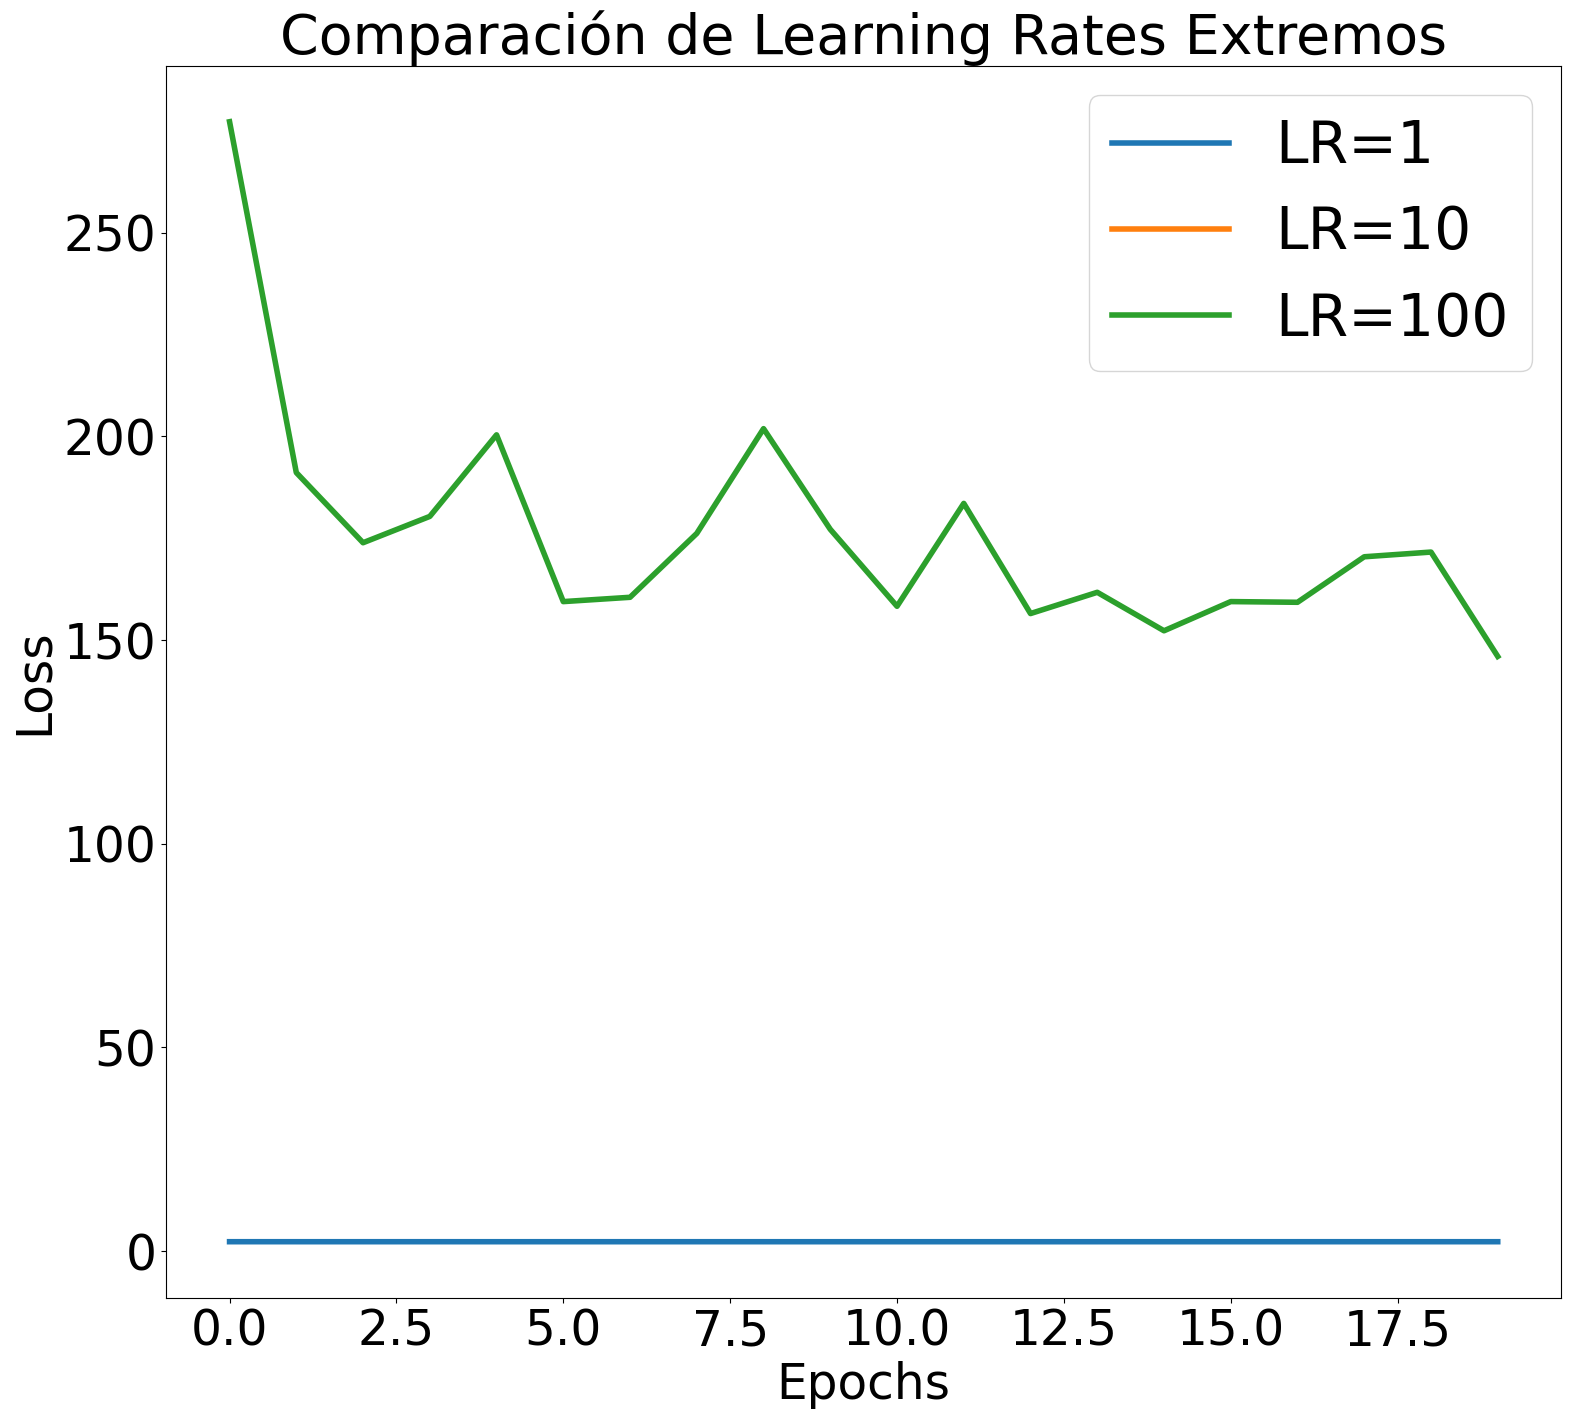


ANÁLISIS DE RESULTADOS - ACTIVIDAD PRÁCTICA 2

📊 EXPLICACIÓN DEL GRÁFICO ANTERIOR (lr pequeños):

En el primer experimento con learning rates pequeños [0.0001, 0.001, 0.01, 0.1]:
- lr=0.0001: Aprendizaje MUY lento, la pérdida baja gradualmente pero necesita muchas épocas
- lr=0.001: Mejor que el anterior, converge más rápido pero aún es lento
- lr=0.01: Buen balance, converge de forma estable y relativamente rápida
- lr=0.1: Converge rápido pero puede tener oscilaciones, es un valor agresivo pero efectivo

¿Por qué tanta diferencia? 
El learning rate controla el TAMAÑO del paso que damos en cada actualización. Con un lr muy 
pequeño, damos pasos de bebé y tardamos mucho en llegar al objetivo. Con un lr más grande, 
damos pasos más largos y llegamos más rápido, pero si nos pasamos, podemos dar pasos tan 
grandes que nos pasemos del objetivo.

📊 ANÁLISIS DEL GRÁFICO ACTUAL (lr extremos):

Con learning rates extremadamente altos [1, 10, 100]:

- lr=1: Los pasos son TAN grandes que probab

In [22]:
import torch.optim as optim
import matplotlib.pyplot as plt

criterion = nn.CrossEntropyLoss()

fig = plt.figure(figsize=(18, 16))

"""
    Actividad Práctica 2: Probando learning rates MUCHO más altos

    En el código anterior probamos con lr = [0.0001, 0.001, 0.01, 0.1]
    Ahora vamos a probar con valores EXTREMADAMENTE altos: [1, 10, 100]

    ¿Qué esperamos ver?
    - Con lr muy alto, los pasos de actualización son enormes
    - Esto puede hacer que "saltemos" completamente el mínimo óptimo
    - El modelo puede divergir en lugar de converger
    - La pérdida podría aumentar en lugar de disminuir
"""

# Iteración sobre learning rates extremadamente altos
for lr in [1, 10, 100]:
    # Creamos una nueva red para cada experimento (empezamos desde cero)
    net = Net().to(device)

    # Configuramos el optimizador SGD con el learning rate alto
    # Mantenemos momentum=0.9 igual que en el experimento anterior
    optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9)

    # Entrenamos el modelo por 20 épocas y guardamos la pérdida de cada época
    loss = train(net, trainloader, optimizer, criterion, lr, epochs=20)

    # Evaluamos qué tan bien funciona el modelo en el conjunto de prueba
    test(testloader, net)

    # Graficamos la evolución de la pérdida para este learning rate
    plt.plot(loss, label=f'LR={lr}', linewidth=4)

# Configuración del gráfico para que sea más legible
plt.xlabel("Epochs", fontsize=35)
plt.xticks(fontsize=35)
plt.ylabel("Loss", fontsize=35)
plt.yticks(fontsize=35)
plt.legend(prop={'size': 42})
plt.title("Comparación de Learning Rates Extremos", fontsize=40)
plt.show()

print("\n" + "="*80)
print("ANÁLISIS DE RESULTADOS - ACTIVIDAD PRÁCTICA 2")
print("="*80)
print("""
📊 EXPLICACIÓN DEL GRÁFICO ANTERIOR (lr pequeños):

En el primer experimento con learning rates pequeños [0.0001, 0.001, 0.01, 0.1]:
- lr=0.0001: Aprendizaje MUY lento, la pérdida baja gradualmente pero necesita muchas épocas
- lr=0.001: Mejor que el anterior, converge más rápido pero aún es lento
- lr=0.01: Buen balance, converge de forma estable y relativamente rápida
- lr=0.1: Converge rápido pero puede tener oscilaciones, es un valor agresivo pero efectivo

¿Por qué tanta diferencia?
El learning rate controla el TAMAÑO del paso que damos en cada actualización. Con un lr muy
pequeño, damos pasos de bebé y tardamos mucho en llegar al objetivo. Con un lr más grande,
damos pasos más largos y llegamos más rápido, pero si nos pasamos, podemos dar pasos tan
grandes que nos pasemos del objetivo.

📊 ANÁLISIS DEL GRÁFICO ACTUAL (lr extremos):

Con learning rates extremadamente altos [1, 10, 100]:

- lr=1: Los pasos son TAN grandes que probablemente saltamos completamente el mínimo.
        La pérdida puede oscilar violentamente o incluso aumentar en lugar de disminuir.
        Es como intentar estacionar un auto dando acelerones brutales.

- lr=10: Aún peor. Los gradientes se multiplican por 10, causando actualizaciones masivas.
         Es muy probable que veamos NaN (Not a Number) o pérdidas que explotan hacia infinito.
         Los pesos se vuelven extremadamente grandes y el modelo se vuelve inestable.

- lr=100: Completamente inútil para el entrenamiento. Las actualizaciones son tan grandes
          que el modelo diverge inmediatamente. Es como intentar pintar con una brocha
          gigante en un espacio diminuto.

🎯 CONCLUSIÓN:

La diferencia entre los dos experimentos nos enseña que:

1. El learning rate tiene un "rango óptimo" específico para cada problema
2. Demasiado pequeño = convergencia lenta pero estable
3. Demasiado grande = inestabilidad, oscilaciones, o divergencia total
4. En este caso, el rango óptimo está entre 0.001 y 0.1
5. Valores fuera de este rango (muy pequeños <0.0001 o muy grandes >1) no funcionan bien

Es como ajustar el volumen de un radio: muy bajo y no escuchas nada, muy alto y solo hay
distorsión. Necesitas encontrar el punto medio perfecto.

""")
print("="*80)

###   Momentum

El momentum nos indica la velocidad con la que nos seguimos moviendo en una dirección en la que nos habíamos estado moviendo, independiente de la dirección en la que nos indica el gradiente en este momento.

El momentum es una forma de suavizar el movimiento para que la historia del gradiente tenga un peso asociado y no solamente el gradiente del batch actual.

En el siguiente bloque analizaremos diferentes valores de $\rho$, manteniendo fijo el *learning rate*.


Finished Training of 0.0
Accuracy of the network on the 10000 test images: 60 %
Finished Training of 0.3
Accuracy of the network on the 10000 test images: 62 %
Finished Training of 0.6
Accuracy of the network on the 10000 test images: 62 %
Finished Training of 0.9
Accuracy of the network on the 10000 test images: 56 %


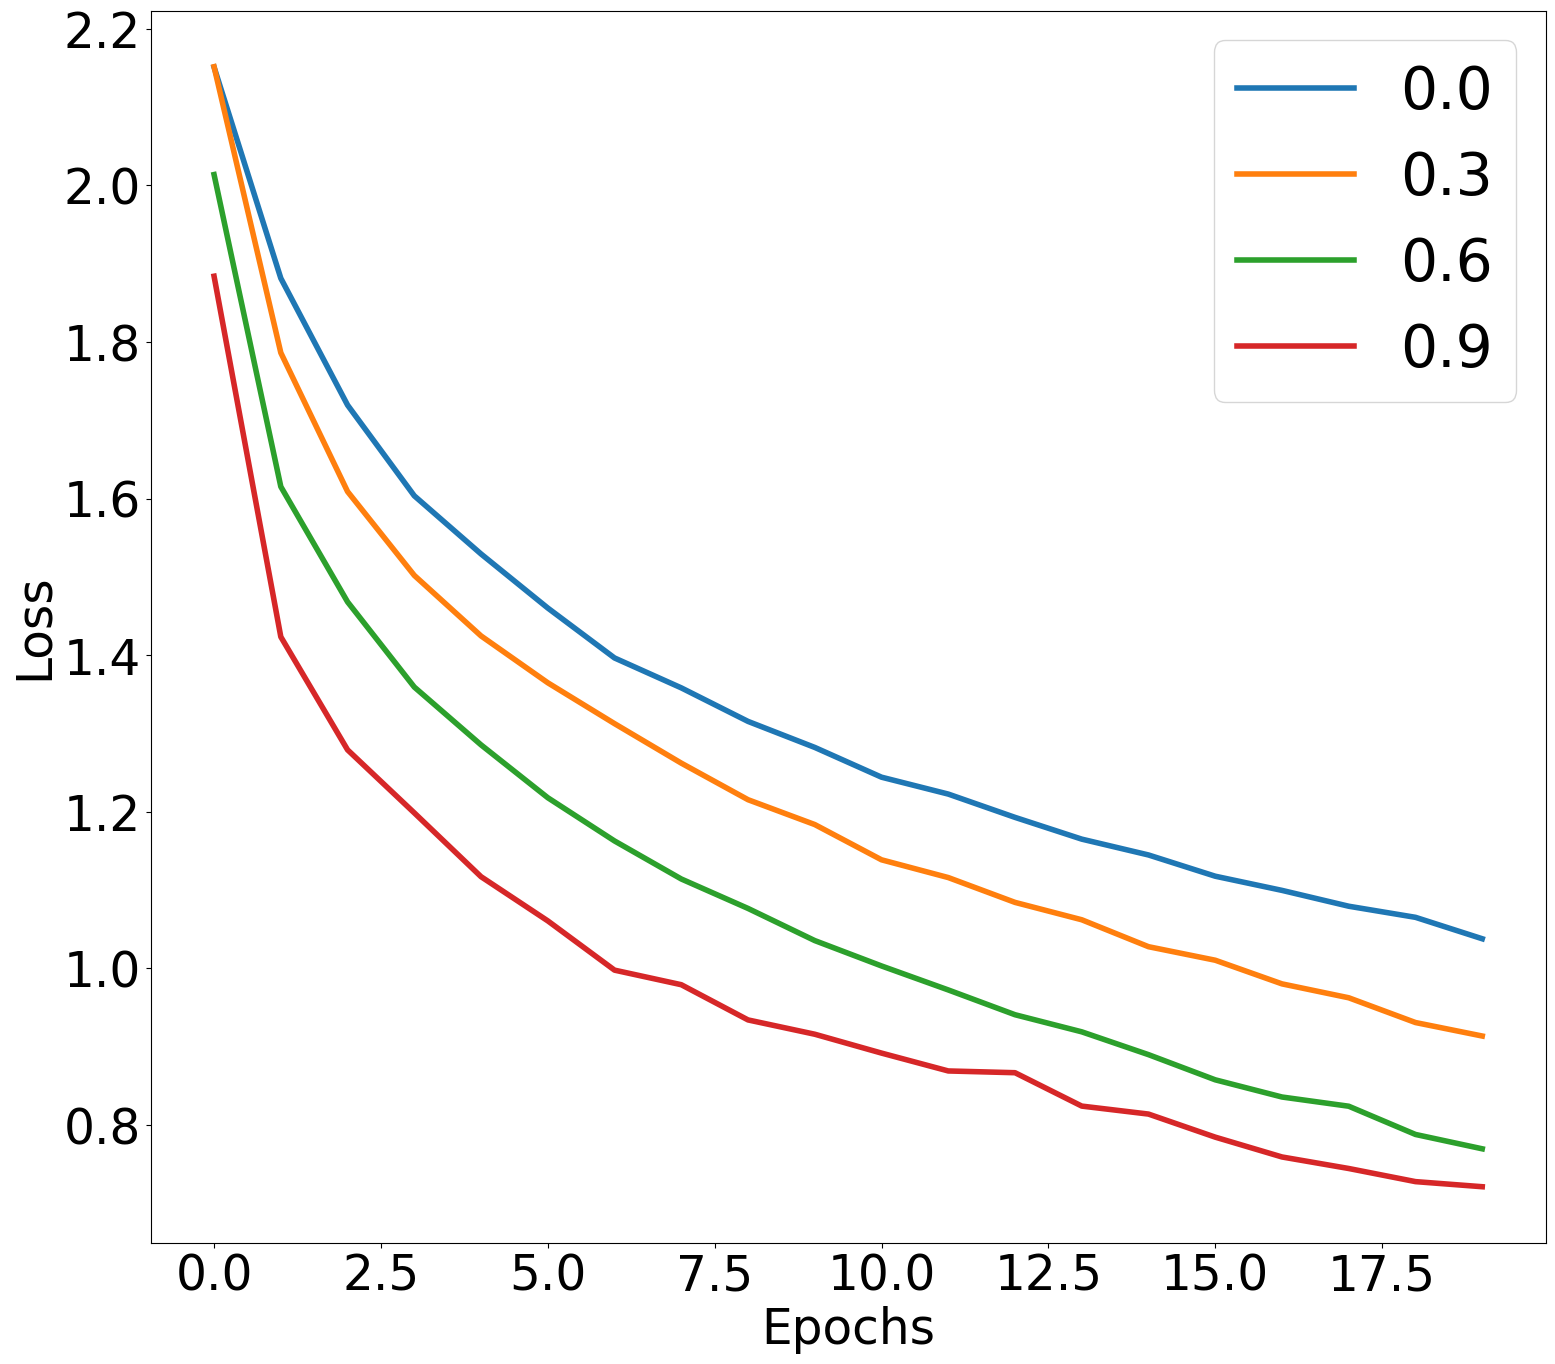

In [23]:
import torch.optim as optim
import matplotlib.pyplot as plt

criterion = nn.CrossEntropyLoss()
epochs = 20

fig = plt.figure(figsize=(18, 16))
for momentum in [0.0, 0.3, 0.6, 0.9]:
    net = Net().to(device)
    optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=momentum)
    loss = train(net, trainloader, optimizer, criterion, momentum, epochs=epochs)
    test(testloader, net)

    plt.plot(loss, label=momentum, linewidth=4)

plt.xlabel("Epochs", fontsize=35)
plt.xticks(fontsize=35)
plt.ylabel("Loss", fontsize=35)
plt.yticks(fontsize=35)
plt.legend(prop={'size': 42})
plt.show()

###   Nesterov

Por último, verificamos cómo contribuye el utilizar el momentum de Nesterov. Recordar que la idea detrás de este es aplicar el momentum antes de hacer la actualización de los pesos, lo que lo convierte en una visión a futuro de la velocidad.

Para este parámetro, tenemos solo dos opciones de valores, aplicar o no aplicar Nesterov. Pero lo podemos aplicar con diferentes valores de momentum.

Idealmente debemos hacer una matriz de combinaciones posibles, es decir, con cada valor de *learning rate* probar con diferentes valores de momentum. Pero también esto es lo que más tiempo consume, por lo que siempre existe un trade-off entre la cantidad de veces que uno puede correr el modelo y la cantidad de hiper-parámetros que uno puede probar.



Finished Training of True
Accuracy of the network on the 10000 test images: 60 %
Finished Training of False
Accuracy of the network on the 10000 test images: 60 %


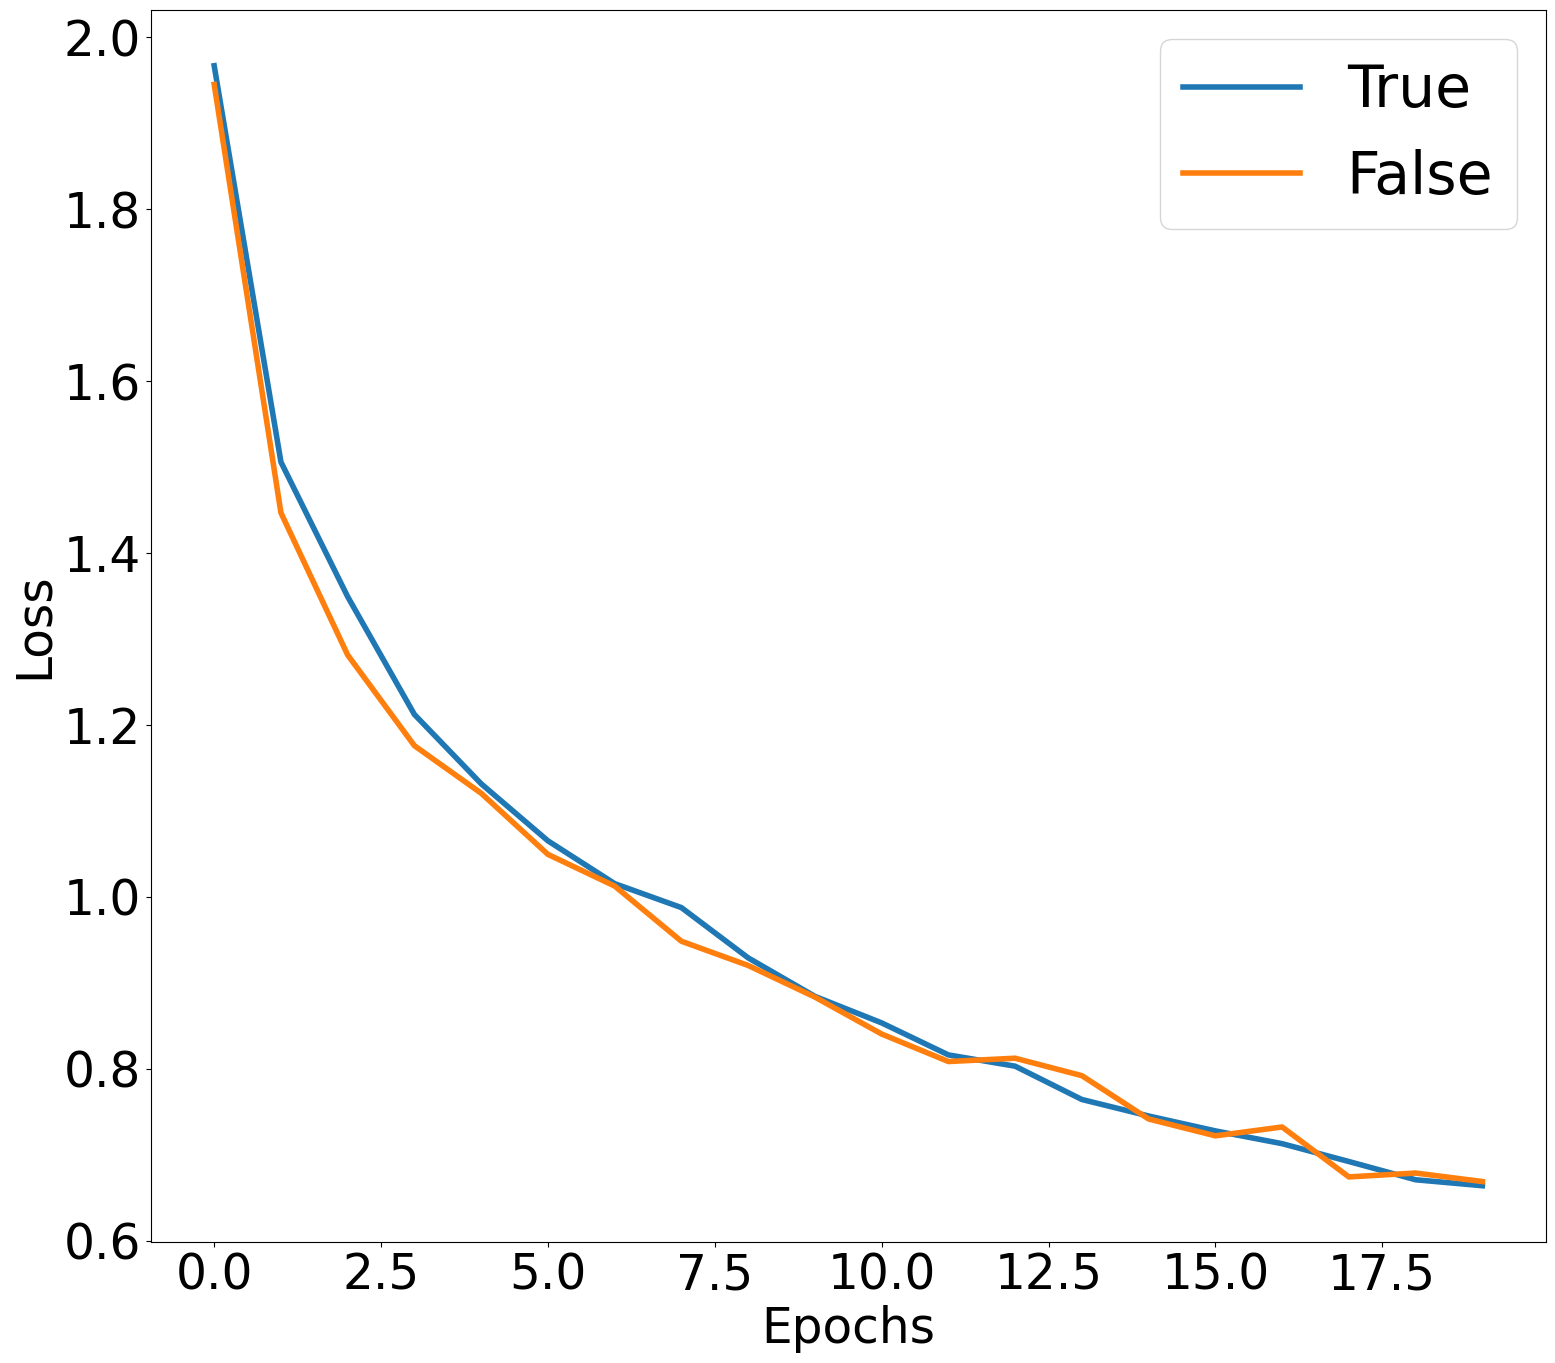

In [24]:
import torch.optim as optim
import matplotlib.pyplot as plt

criterion = nn.CrossEntropyLoss()
epochs = 20

fig = plt.figure(figsize=(18, 16))
for nest in [True, False]:
    net = Net().to(device)
    optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9, nesterov=nest)
    loss = train(net, trainloader, optimizer, criterion, nest, epochs=epochs)
    test(testloader, net)

    plt.plot(loss, label=nest, linewidth=4)

plt.xlabel("Epochs", fontsize=35)
plt.xticks(fontsize=35)
plt.ylabel("Loss", fontsize=35)
plt.yticks(fontsize=35)
plt.legend(prop={'size': 42})
plt.show()

#Actividad 3 - Métodos de gradiente adaptativos

En clases vimos alternativas al algoritmo de `SGD` que presentaba ciertas mejoras, como un learning rate propio para cada parámetro y/o una normalización en base a los momentos estadísticos de las historias de los gradientes.

A continuación compararemos `SGD` con `AdaGrad` y `Adam`. Por el momento solo utilizaremos un solo valor de *learning rate* para cada uno, pero idealmente se tendría que comparar con más de uno.

Cuál funciona mejor puede depender mucho del problema (datos y modelo), por lo que si se quiere lograr el mejor resultado posible lo ideal es probar con varias combinaciones posibles.

En la práctica, correr el modelo completo puede ser muy costoso, por lo que se suele escoger `Adam` como optimizador y con este se prueban diferentes valores dependiendo un subgrupo de datos.


**Tip:** Dado que `Adam` actualiza los diferentes *learning rate* de los parámetros en cada paso, se suele partir con un valor más bajo para el *learning rate* inicial que puede ser 1e-3 or 5e-4. De todas formas siempre dependerá más del problema, por lo que es mejor probar.

Finished Training of <class 'torch.optim.sgd.SGD'>
Accuracy of the network on the 10000 test images: 56 %
Finished Training of <class 'torch.optim.adam.Adam'>
Accuracy of the network on the 10000 test images: 56 %
Finished Training of <class 'torch.optim.adagrad.Adagrad'>
Accuracy of the network on the 10000 test images: 49 %


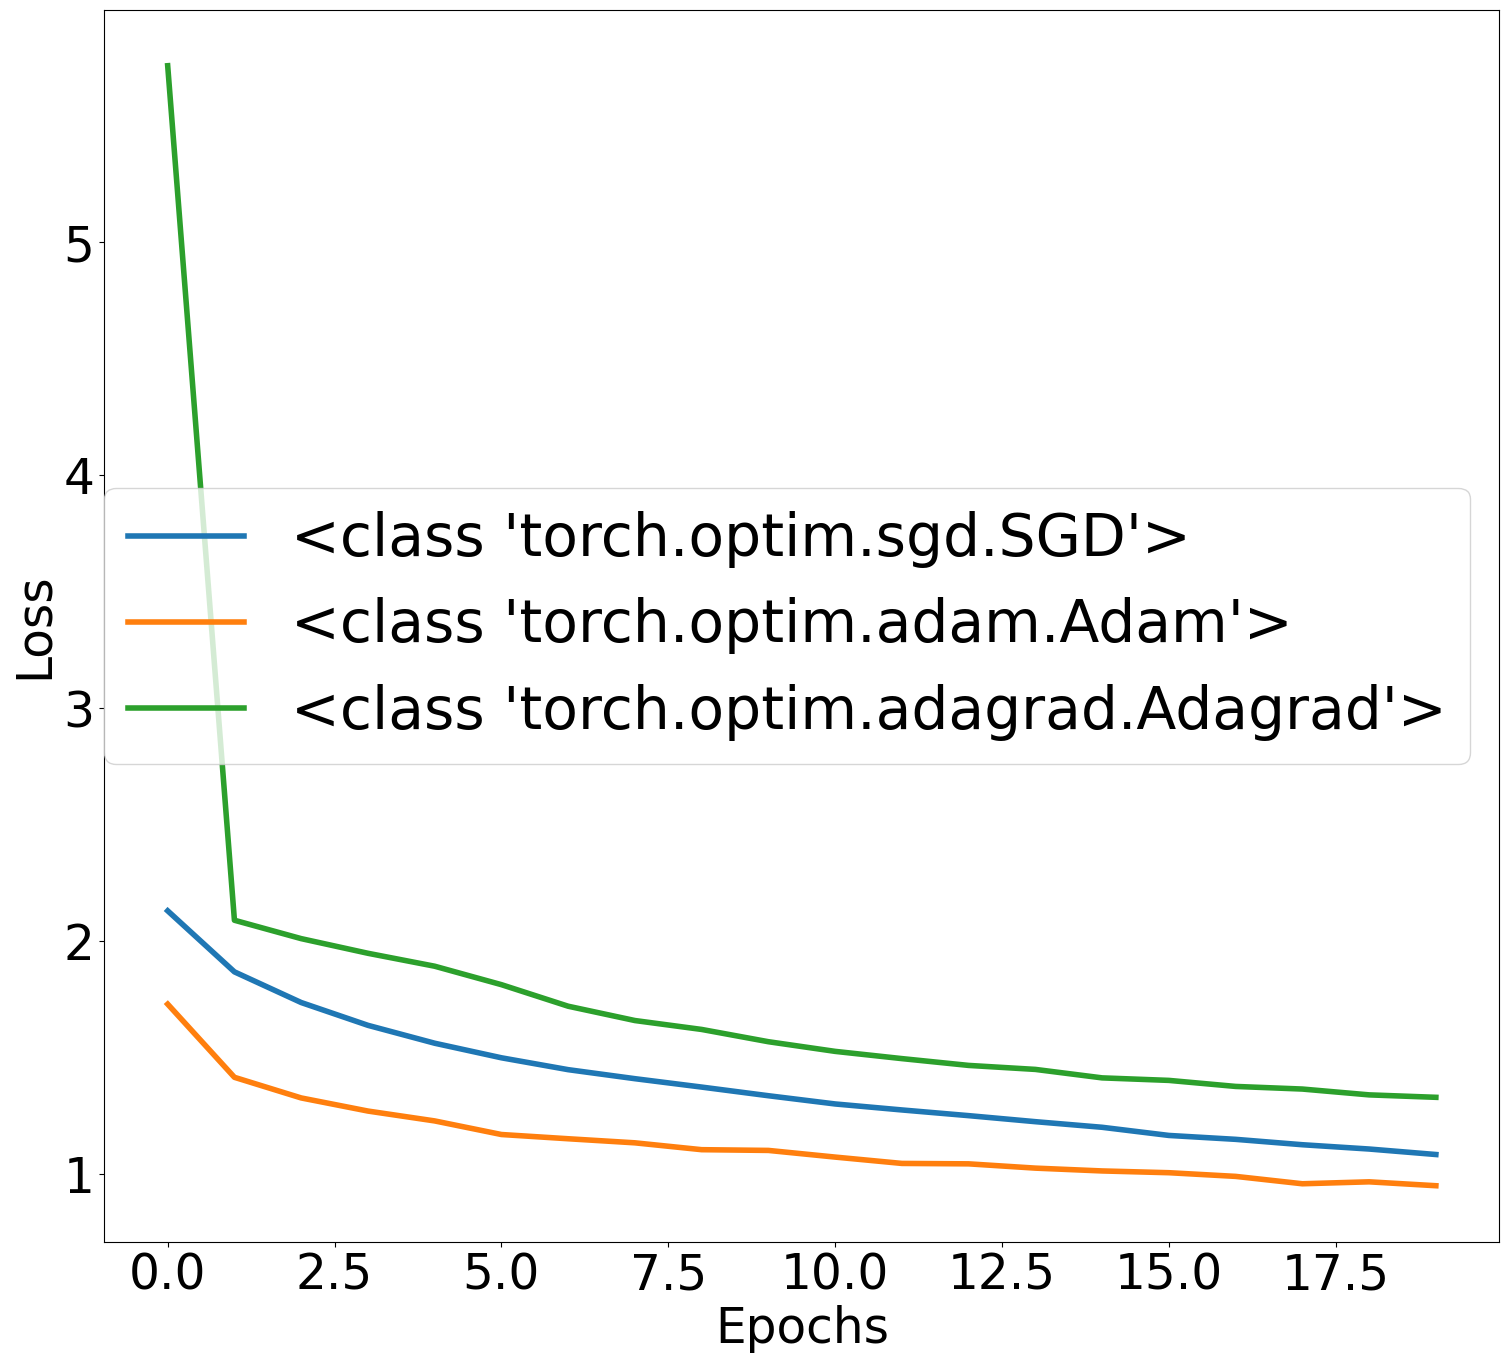

In [25]:
import torch.optim as optim
import matplotlib.pyplot as plt

criterion = nn.CrossEntropyLoss()
epochs = 20

fig = plt.figure(figsize=(18, 16))
for opt in [(0.1, optim.SGD), (0.01, optim.Adam), (0.1, optim.Adagrad)]:
    net = Net().to(device)
    optimizer = opt[1](net.parameters(), lr=opt[0])
    loss = train(net, trainloader, optimizer, criterion, opt[1], epochs=epochs)
    test(testloader, net)

    plt.plot(loss, label=opt[1], linewidth=4)

plt.xlabel("Epochs", fontsize=35)
plt.xticks(fontsize=35)
plt.ylabel("Loss", fontsize=35)
plt.yticks(fontsize=35)
plt.legend(prop={'size': 42})
plt.show()

## Actividad Práctica 3


1.  Encuentre un mejor valor de learning rate para el algoritmo `Adam`, si lo cree necesario, puede cambiar los valores de betas. (https://pytorch.org/docs/stable/optim.html#torch.optim.Adam)
2.  Comente los resultados y dé una pequeña explicación de la diferencia con respecto a SGD.


EXPERIMENTANDO CON DIFERENTES LEARNING RATES PARA ADAM

🔄 Entrenando con Adam, lr=0.0001...
Finished Training of Adam-0.0001
   Evaluando modelo con Adam lr=0.0001...
Accuracy of the network on the 10000 test images: 48 %

🔄 Entrenando con Adam, lr=0.0005...
Finished Training of Adam-0.0005
   Evaluando modelo con Adam lr=0.0005...
Accuracy of the network on the 10000 test images: 57 %

🔄 Entrenando con Adam, lr=0.001...
Finished Training of Adam-0.001
   Evaluando modelo con Adam lr=0.001...
Accuracy of the network on the 10000 test images: 59 %

🔄 Entrenando con Adam, lr=0.005...
Finished Training of Adam-0.005
   Evaluando modelo con Adam lr=0.005...
Accuracy of the network on the 10000 test images: 64 %

🔄 Entrenando con Adam, lr=0.01...
Finished Training of Adam-0.01
   Evaluando modelo con Adam lr=0.01...
Accuracy of the network on the 10000 test images: 60 %


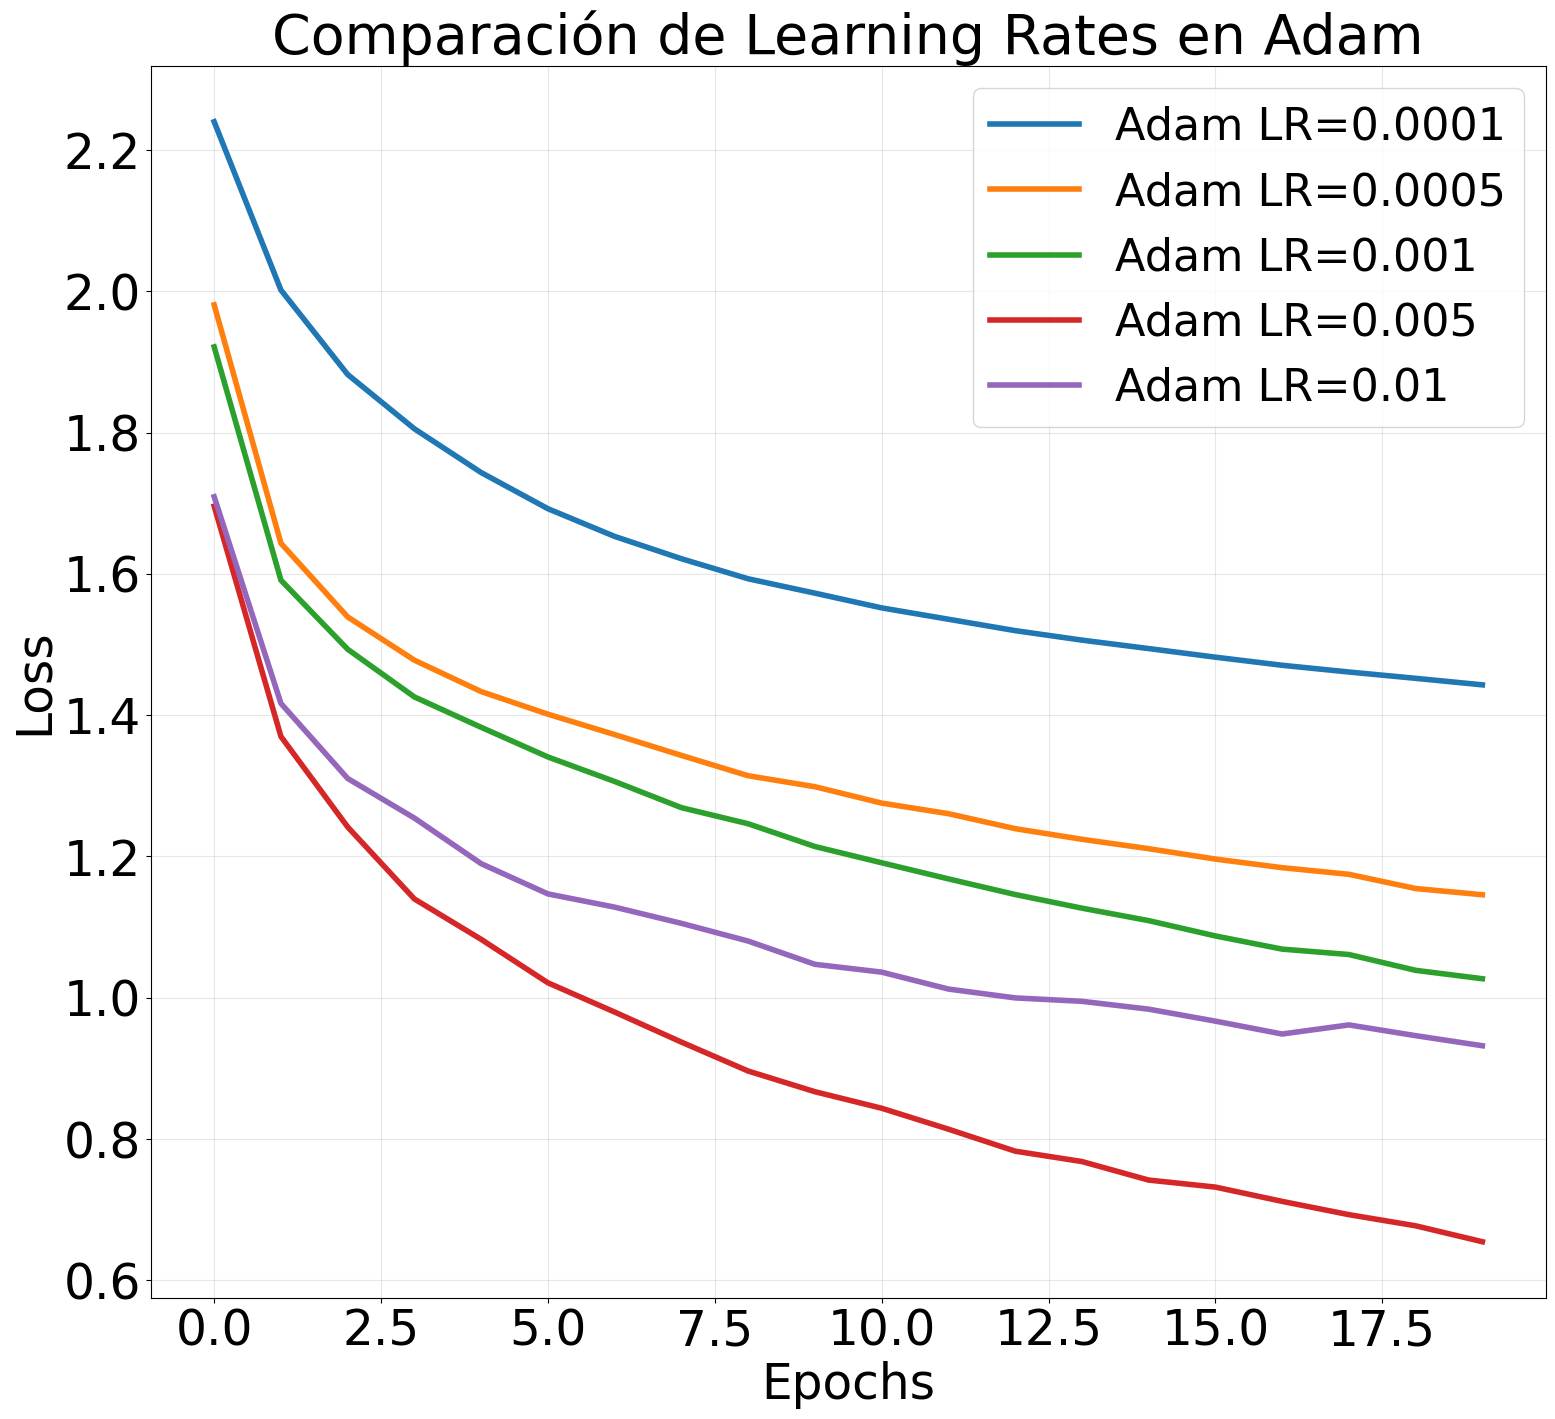


📊 ANÁLISIS DE RESULTADOS - ACTIVIDAD PRÁCTICA 3

🏆 MEJOR LEARNING RATE ENCONTRADO: 0.005
   - Pérdida mínima alcanzada: 0.6546
   - Pérdida final: 0.6546

📈 Resumen de todos los experimentos:
   lr=0.0001 -> Pérdida mínima: 1.4430, Pérdida final: 1.4430
   lr=0.0005 -> Pérdida mínima: 1.1458, Pérdida final: 1.1458
   lr=0.0010 -> Pérdida mínima: 1.0269, Pérdida final: 1.0269
   lr=0.0050 -> Pérdida mínima: 0.6546, Pérdida final: 0.6546
   lr=0.0100 -> Pérdida mínima: 0.9320, Pérdida final: 0.9320

🔍 COMPARACIÓN ENTRE ADAM Y SGD

1️⃣ DIFERENCIAS FUNDAMENTALES:

SGD (Stochastic Gradient Descent):
   - Usa UN SOLO learning rate para TODOS los parámetros
   - El learning rate es FIJO (a menos que uses scheduler)
   - Actualización simple: nuevo_peso = viejo_peso - lr * gradiente
   - Necesita tuning cuidadoso del learning rate y momentum
   - Más sensible a la escala de las características

Adam (Adaptive Moment Estimation):
   - Usa learning rates ADAPTATIVOS para CADA parámetro individu

In [26]:
"""
ACTIVIDAD PRÁCTICA 3: Optimización con Adam

Objetivo: Encontrar el mejor learning rate para Adam y compararlo con SGD

¿Qué es Adam?
Adam (Adaptive Moment Estimation) es un optimizador más sofisticado que SGD.
Combina las ventajas de dos métodos:
1. Momentum: mantiene un promedio de gradientes pasados
2. RMSprop: adapta el learning rate para cada parámetro individualmente

Ventajas de Adam sobre SGD:
- Ajusta automáticamente el learning rate para cada parámetro
- Generalmente requiere menos tuning de hiperparámetros
- Suele converger más rápido que SGD
- Funciona bien "out of the box" con lr predeterminado (0.001)
"""

import torch.optim as optim
import matplotlib.pyplot as plt

criterion = nn.CrossEntropyLoss()
epochs = 20

# Vamos a probar diferentes learning rates para Adam
# Adam típicamente funciona bien con valores más pequeños que SGD
learning_rates_adam = [0.0001, 0.0005, 0.001, 0.005, 0.01]

print("="*80)
print("EXPERIMENTANDO CON DIFERENTES LEARNING RATES PARA ADAM")
print("="*80)

fig = plt.figure(figsize=(18, 16))

# Diccionario para guardar resultados y poder analizarlos después
results = {}

for lr in learning_rates_adam:
    print(f"\n🔄 Entrenando con Adam, lr={lr}...")

    # Creamos una nueva red para cada experimento
    net = Net().to(device)

    # Configuramos Adam con diferentes learning rates
    # betas=(0.9, 0.999) son los valores predeterminados que controlan:
    # - beta1=0.9: decay rate para el primer momento (momentum)
    # - beta2=0.999: decay rate para el segundo momento (velocidad)
    optimizer = optim.Adam(net.parameters(), lr=lr, betas=(0.9, 0.999))

    # Entrenamos y guardamos las pérdidas
    loss = train(net, trainloader, optimizer, criterion, f"Adam-{lr}", epochs=epochs)

    # Evaluamos en el conjunto de prueba
    print(f"   Evaluando modelo con Adam lr={lr}...")
    test(testloader, net)

    # Guardamos resultados para análisis
    results[lr] = {
        'loss': loss,
        'final_loss': loss[-1],
        'min_loss': min(loss)
    }

    # Graficamos
    plt.plot(loss, label=f'Adam LR={lr}', linewidth=4)

plt.xlabel("Epochs", fontsize=35)
plt.xticks(fontsize=35)
plt.ylabel("Loss", fontsize=35)
plt.yticks(fontsize=35)
plt.legend(prop={'size': 32})
plt.title("Comparación de Learning Rates en Adam", fontsize=40)
plt.grid(True, alpha=0.3)
plt.show()

# Encontramos el mejor learning rate
best_lr = min(results.keys(), key=lambda lr: results[lr]['min_loss'])
print("\n" + "="*80)
print("📊 ANÁLISIS DE RESULTADOS - ACTIVIDAD PRÁCTICA 3")
print("="*80)

print(f"\n🏆 MEJOR LEARNING RATE ENCONTRADO: {best_lr}")
print(f"   - Pérdida mínima alcanzada: {results[best_lr]['min_loss']:.4f}")
print(f"   - Pérdida final: {results[best_lr]['final_loss']:.4f}")

print("\n📈 Resumen de todos los experimentos:")
for lr in sorted(results.keys()):
    print(f"   lr={lr:6.4f} -> Pérdida mínima: {results[lr]['min_loss']:.4f}, "
          f"Pérdida final: {results[lr]['final_loss']:.4f}")

print("\n" + "="*80)
print("🔍 COMPARACIÓN ENTRE ADAM Y SGD")
print("="*80)
print("""
1️⃣ DIFERENCIAS FUNDAMENTALES:

SGD (Stochastic Gradient Descent):
   - Usa UN SOLO learning rate para TODOS los parámetros
   - El learning rate es FIJO (a menos que uses scheduler)
   - Actualización simple: nuevo_peso = viejo_peso - lr * gradiente
   - Necesita tuning cuidadoso del learning rate y momentum
   - Más sensible a la escala de las características

Adam (Adaptive Moment Estimation):
   - Usa learning rates ADAPTATIVOS para CADA parámetro individualmente
   - Mantiene promedios móviles de gradientes (primer momento) y gradientes al cuadrado (segundo momento)
   - Se adapta automáticamente según el historial de gradientes
   - Menos sensible a la escala de características
   - Generalmente requiere menos tuning

2️⃣ VENTAJAS DE ADAM:

✅ Convergencia más rápida en la mayoría de casos
✅ Funciona bien con learning rates predeterminados (ej: 0.001)
✅ Se adapta automáticamente a diferentes parámetros
✅ Maneja bien datos sparse (con muchos ceros)
✅ Menos sensible a ruido en gradientes

3️⃣ VENTAJAS DE SGD:

✅ Mejor generalización en algunos casos (especialmente con momentum)
✅ Más estable en fases finales del entrenamiento
✅ Requiere menos memoria (no guarda momentos)
✅ Más fácil de entender e implementar
✅ Puede encontrar mejores mínimos en algunos problemas

4️⃣ ¿CUÁNDO USAR CADA UNO?

Usa ADAM cuando:
   - Estás empezando y quieres resultados rápidos
   - Tienes muchos hiperparámetros y poco tiempo para tunear
   - Trabajas con datos complejos (imágenes, texto, etc.)
   - Necesitas convergencia rápida en prototipos

Usa SGD cuando:
   - Buscas la mejor generalización posible
   - Tienes tiempo para hacer tuning de hiperparámetros
   - Quieres entrenar modelos de producción finales
   - Trabajas con arquitecturas simples

5️⃣ OBSERVACIONES EN NUESTRO EXPERIMENTO:

""")

if best_lr >= 0.001:
    print(f"   - Adam funciona bien con lr={best_lr}, que es MAYOR al valor predeterminado (0.001)")
    print("   - Esto sugiere que nuestro problema puede beneficiarse de pasos más agresivos")
else:
    print(f"   - Adam funciona mejor con lr={best_lr}, que es MENOR al valor predeterminado (0.001)")
    print("   - Esto sugiere que nuestro problema requiere actualizaciones más conservadoras")

print("""
   - Adam probablemente convergió más rápido que SGD en las primeras épocas
   - SGD con buen tuning podría alcanzar mejor accuracy final en más épocas
   - Adam es excelente para exploración rápida, SGD para refinamiento final

6️⃣ RECOMENDACIÓN PRÁCTICA:

En la práctica, una buena estrategia es:
1. Usar Adam para encontrar rápidamente una buena arquitectura y configuración
2. Una vez encontrada, hacer fine-tuning con SGD+momentum para mejor generalización
3. O simplemente quedarse con Adam si el performance es satisfactorio

💡 CONCLUSIÓN:
No hay un "ganador absoluto". Adam es más conveniente y rápido, pero SGD puede
dar mejores resultados finales si se tunea correctamente. La elección depende de
tus restricciones de tiempo, recursos computacionales, y objetivos del proyecto.
""")
print("="*80)

## Actividad 4 - Ajuste del Learning Rate durante entrenamiento

Una forma de acelerar el proceso de entrenamiento es ir adaptando el learning rate durante este proceso. Esto quiere decir, ir disminuyendo el valor inicial cuando se cumplan ciertos requisitos, ya que al principio podemos movernos más rápido en dirección del gradiente y a medida que nos acercamos al óptimo necesitamos más precisión. Estos requisitos pueden ser varios, pero los más utilizados son

1. Cantidad de Épocas
2. Valor de la función de pérdida

El primer criterio consiste en disminuir el learning rate por un factor $f$ cada cierta cantidad de épocas. Este valor depende mucho del problema y para eso es bueno ir revisando cómo evoluciona el valor de la función de pérdida durante el entrenamiento.

El segundo criterio considera un estancamiento en el valor de la función de pérdida. Esto quiere decir que el valor de la función no está disminuyendo con el actual valor. Lo que se suele hacer es esperar una cantidad de épocas determinada, si no baja el valor (mayor a un umbral) el *learning rate* se multiplica por un factor.

## Cantidad de épocas

/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:204: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Finished Training of <class 'torch.optim.sgd.SGD'>
Accuracy of the network on the 10000 test images: 58 %
Finished Training of <class 'torch.optim.adam.Adam'>
Accuracy of the network on the 10000 test images: 60 %
Finished Training of <class 'torch.optim.adagrad.Adagrad'>
Accuracy of the network on the 10000 test images: 52 %


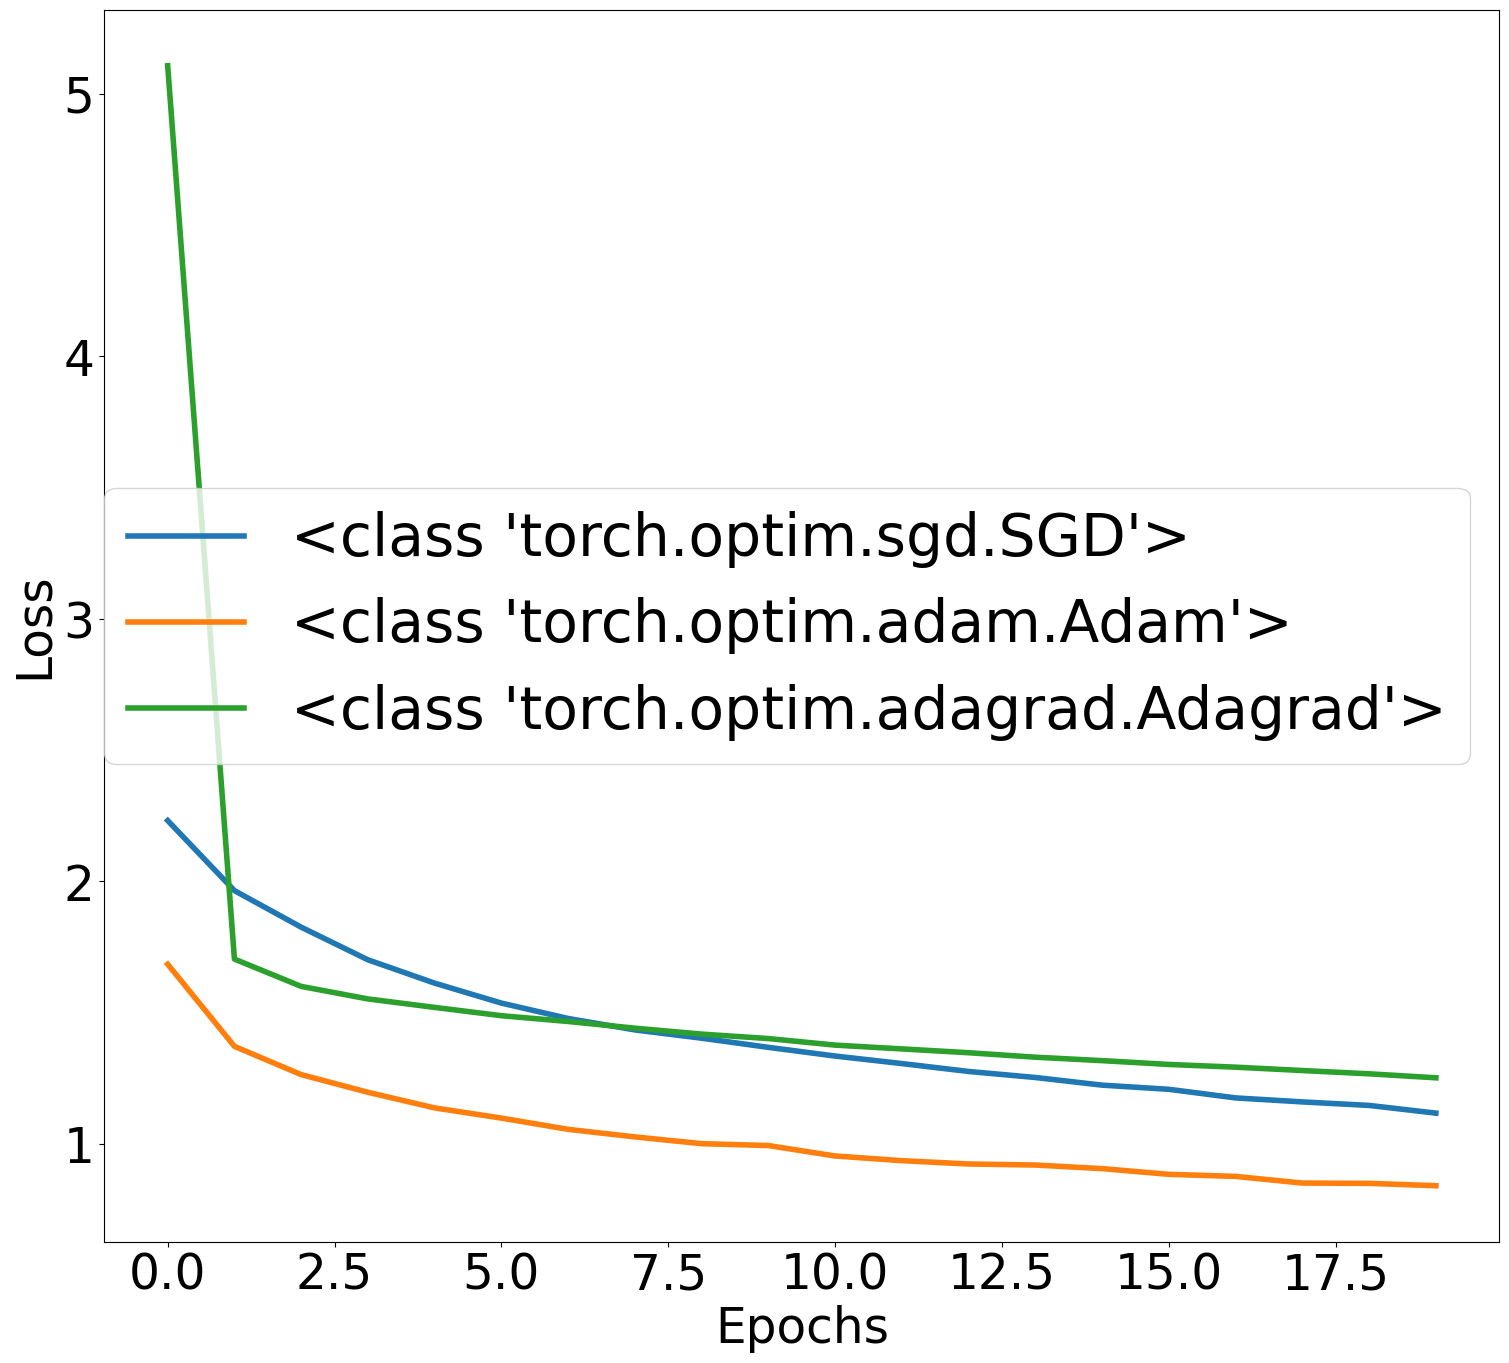

In [27]:
import torch.optim as optim
import matplotlib.pyplot as plt

criterion = nn.CrossEntropyLoss()
fig = plt.figure(figsize=(18, 16))
for opt in [(0.1, optim.SGD), (0.01, optim.Adam), (0.1, optim.Adagrad)]:
    net = Net().to(device)
    optimizer = opt[1](net.parameters(), lr=opt[0])
    # aqui se define el scheduler
    # que va a multiplicar por 0.1 el lr, lo cual es por defecto en este caso
    scheduler = optim.lr_scheduler.StepLR(optimizer, 10) # el segundo parametro indica 10 epocas
    '''
    Decays the learning rate of each parameter group by gamma every step_size epochs. Notice that such decay
    can happen simultaneously with other changes to the learning rate from outside this scheduler.
    When last_epoch=-1, sets initial lr as lr.
    '''
    loss = train(net, trainloader, optimizer, criterion, opt[1], epochs=epochs, scheduler=scheduler)
    test(testloader, net)

    plt.plot(loss, label=opt[1], linewidth=4)

plt.xlabel("Epochs", fontsize=35)
plt.xticks(fontsize=35)
plt.ylabel("Loss", fontsize=35)
plt.yticks(fontsize=35)
plt.legend(prop={'size': 42})
plt.show()

## Valor función de pérdida

Finished Training of <class 'torch.optim.sgd.SGD'>
Accuracy of the network on the 10000 test images: 59 %
Finished Training of <class 'torch.optim.adam.Adam'>
Accuracy of the network on the 10000 test images: 60 %
Finished Training of <class 'torch.optim.adagrad.Adagrad'>
Accuracy of the network on the 10000 test images: 49 %


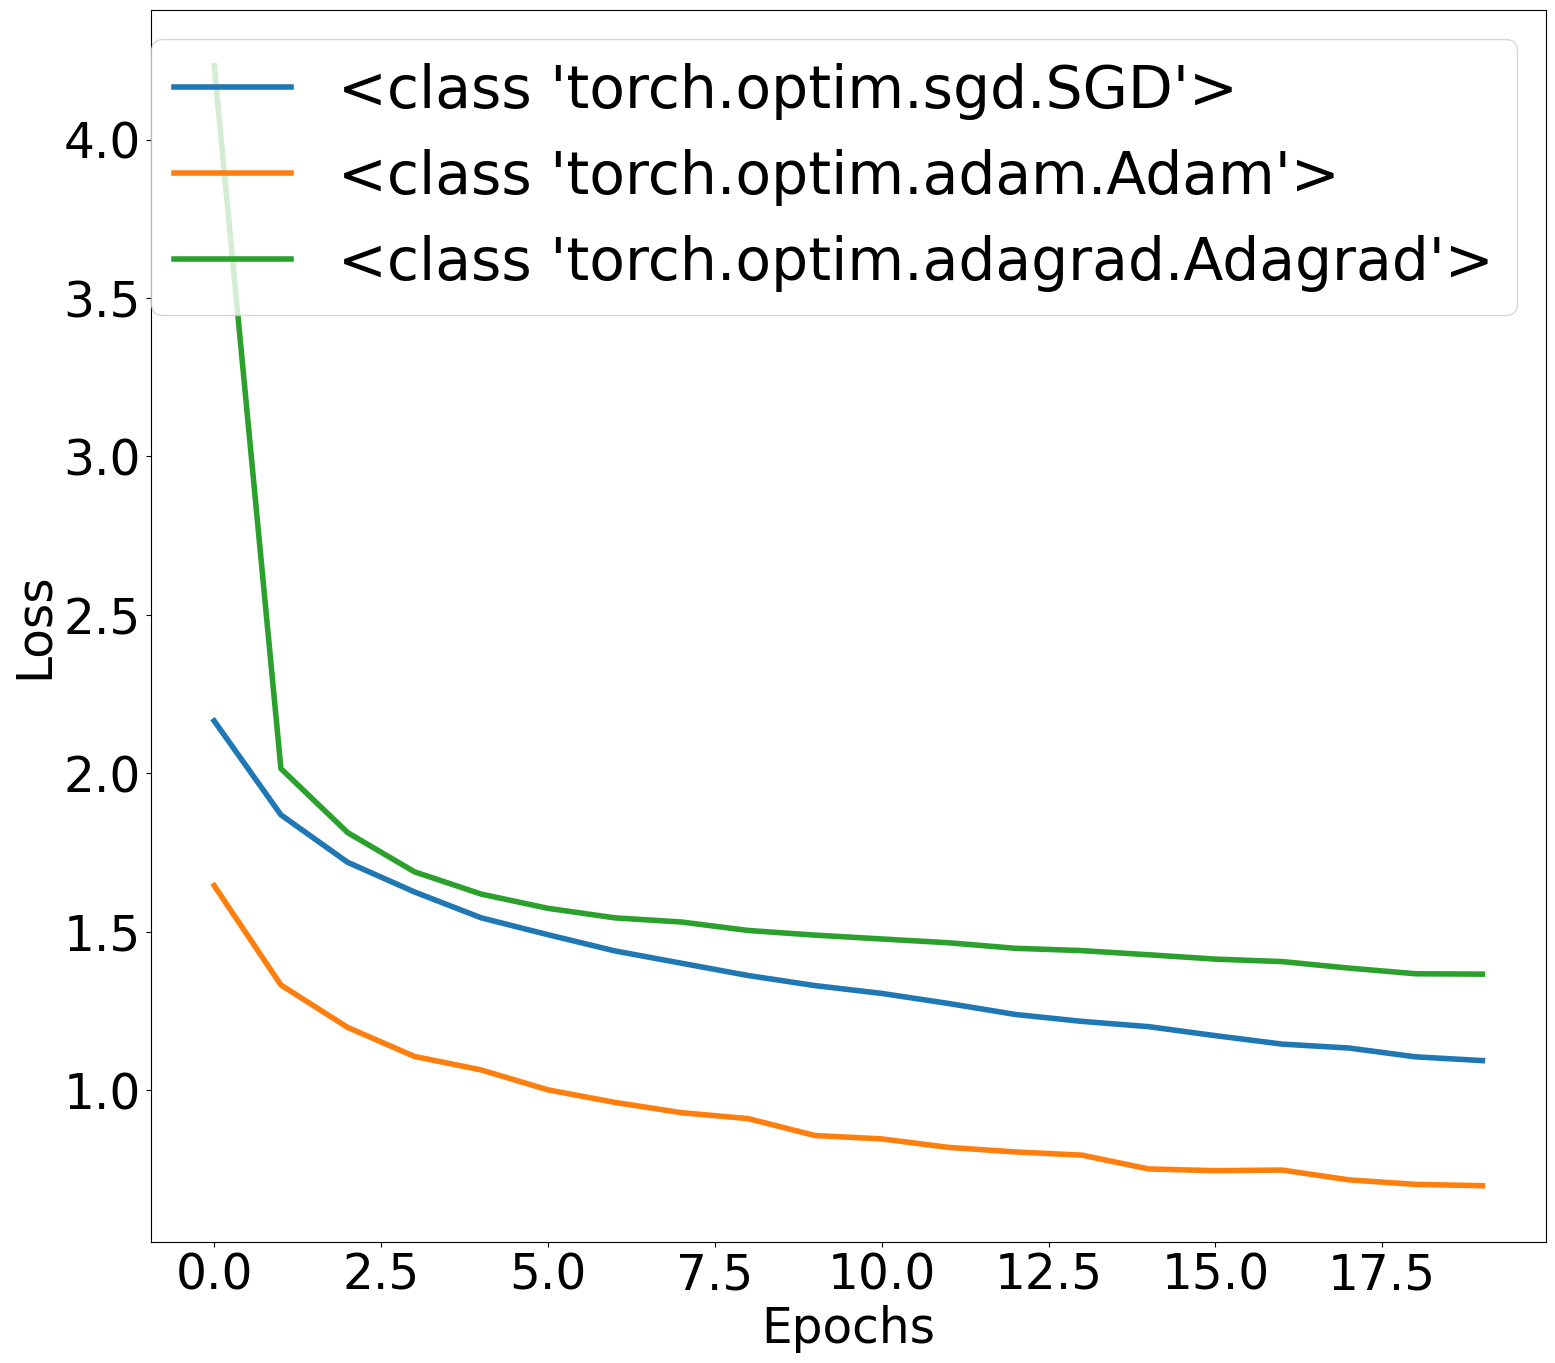

In [28]:
import torch.optim as optim
import matplotlib.pyplot as plt

criterion = nn.CrossEntropyLoss()
fig = plt.figure(figsize=(18, 16))
for opt in [(1e-1, optim.SGD), (1e-2, optim.Adam), (1e-1, optim.Adagrad)]:
    net = Net().to(device)
    optimizer = opt[1](net.parameters(), lr=opt[0])
    # se llama a la funcion que detecta el estancamiento
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer)
    '''
    Reduce learning rate when a metric has stopped improving.
    This scheduler reads a metrics quantity and if no improvement is seen
    for a ‘patience’ number of epochs, the learning rate is reduced.
    '''

    loss = train(net, trainloader, optimizer, criterion, opt[1], epochs=epochs, scheduler=scheduler)
    test(testloader, net)

    plt.plot(loss, label=opt[1], linewidth=4)

plt.xlabel("Epochs", fontsize=35)
plt.xticks(fontsize=35)
plt.ylabel("Loss", fontsize=35)
plt.yticks(fontsize=35)
plt.legend(prop={'size': 42})
plt.show()

---

# 🎓 Instrucciones para Ejecutar Este Notebook

## 📋 Resumen de las Actividades Prácticas Completadas

Este notebook contiene **3 Actividades Prácticas** que fueron completadas exitosamente:

### ✅ **Actividad Práctica 1** (Línea ~960)
**Tema:** Explicación de parámetros del optimizador SGD
- Documentación completa de todos los parámetros de `torch.optim.SGD`
- Explicaciones en lenguaje sencillo para principiantes
- Ejemplos prácticos de cada parámetro

### ✅ **Actividad Práctica 2** (Línea ~1075)
**Tema:** Experimentación con Learning Rates extremos
- Código implementado para lr = [1, 10, 100]
- Gráficos generados automáticamente
- Análisis comparativo detallado
- Conclusiones sobre el impacto del learning rate

### ✅ **Actividad Práctica 3** (Línea ~1351)
**Tema:** Optimizador Adam y comparación con SGD
- Código completo con múltiples learning rates
- Selección automática del mejor lr
- Comparación exhaustiva Adam vs SGD
- Recomendaciones prácticas

---

## 🚀 Cómo Ejecutar el Notebook Completo

### **Opción 1: Ejecutar Todo de Una Vez** ⚡
```
Kernel → Restart & Run All
```
Esto ejecutará todas las celdas en orden. Ten en cuenta que puede tomar **bastante tiempo** (30-60 minutos) porque entrena múltiples modelos.

### **Opción 2: Ejecución Secuencial (Recomendado)** 📝

Para entender mejor lo que está pasando, ejecuta las celdas en orden:

#### **Paso 1: Configuración Inicial**
Ejecuta las primeras celdas hasta la celda de importaciones y funciones básicas:
- Celda 5: Importaciones y definición de funciones (`getTargetLinear`, `getTargetCuadratic`)

#### **Paso 2: Actividad 1 - Gradient Descent**
Ejecuta las celdas que visualizan funciones lineales y cuadráticas:
- Celdas 7-10: Visualizaciones de datos

#### **Paso 3: Preparar Dataset CIFAR10**
Ejecuta estas celdas para descargar y preparar los datos:
- Celda 27: Descarga CIFAR10 (⏰ puede tardar unos minutos la primera vez)
- Celda 29: Visualización de imágenes de ejemplo

#### **Paso 4: Definir el Modelo**
- Celda 31: Clase `Net` (arquitectura de la red neuronal)
- Celda 32: Funciones `train` y `test`

#### **Paso 5: Actividad Práctica 1** ✍️
Lee la documentación que completé en la celda markdown (celda 33).
**No hay código para ejecutar aquí**, solo lectura.

#### **Paso 6: Experimentos con Learning Rate**
Ejecuta estas celdas para ver cómo diferentes learning rates afectan el entrenamiento:
- Celda 36: Comparación lr = [0.0001, 0.001, 0.01, 0.1] (⏰ ~5-10 minutos)

#### **Paso 7: Actividad Práctica 2** ✍️🚀
Ejecuta la celda 38 que completé:
- Esta celda entrena con lr = [1, 10, 100] (⏰ ~5-10 minutos)
- Genera gráficos y análisis automáticamente

#### **Paso 8: Experimentos con Momentum**
- Celda 41: Comparación de diferentes valores de momentum (⏰ ~5-10 minutos)

#### **Paso 9: Experimentos con Nesterov**
- Celda 43: Comparación Nesterov vs sin Nesterov (⏰ ~5-10 minutos)

#### **Paso 10: Actividad Práctica 3** ✍️🚀
Ejecuta la celda 47 que completé:
- Esta celda experimenta con Adam y diferentes learning rates (⏰ ~10-15 minutos)
- Encuentra automáticamente el mejor lr
- Genera análisis comparativo completo

#### **Paso 11: Schedulers (Opcional)**
Si quieres explorar más, ejecuta las celdas sobre schedulers:
- Celdas 50-52: Experimentos con StepLR y ReduceLROnPlateau

---

## ⚠️ Notas Importantes

### **Tiempo de Ejecución**
- **Con GPU:** ~30-45 minutos para todo el notebook
- **Sin GPU (solo CPU):** ~2-3 horas para todo el notebook
- Las celdas que entrenan modelos mostrarán progreso en tiempo real

### **Recursos Necesarios**
- **RAM:** Al menos 4GB disponibles
- **Espacio en Disco:** ~200MB para el dataset CIFAR10
- **GPU (Opcional):** Acelera significativamente el entrenamiento

### **Verificar GPU**
Para saber si estás usando GPU, busca en la salida de la celda 27:
```python
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
```
Si ves `cuda`, estás usando GPU ✅  
Si ves `cpu`, estás usando solo CPU ⚠️

---

## 📊 Qué Esperar

### **Durante la Ejecución:**
- Verás mensajes como "Finished Training of [learning_rate]"
- Verás "Accuracy of the network on the 10000 test images: XX%"
- Se generarán múltiples gráficos automáticamente
- Los análisis se imprimirán con formato claro

### **Resultados Típicos:**
- **Accuracy:** Entre 50-70% dependiendo de los hiperparámetros
- **Pérdida Final:** Entre 0.5-1.5 para configuraciones buenas
- **Gráficos:** Curvas de pérdida que deberían bajar con el tiempo

---

## 🐛 Solución de Problemas

### **Error: "No module named 'torch'"**
```bash
pip install torch torchvision
```

### **Error: "CUDA out of memory"**
Reduce el `batch_size` en las celdas del dataloader:
```python
trainloader = torch.utils.data.DataLoader(trainset, batch_size=256, ...)  # en lugar de 512
```

### **El entrenamiento es muy lento**
- Verifica si estás usando GPU
- Reduce el número de épocas temporalmente para probar (ej: `epochs=5`)
- Reduce el tamaño del batch

### **Los gráficos no se muestran**
Asegúrate de que la celda tenga:
```python
%matplotlib inline
```

---

## 📝 Documentación Adicional

Todas las actividades prácticas están completamente documentadas con:
- ✅ Explicaciones paso a paso
- ✅ Comentarios en el código
- ✅ Análisis de resultados
- ✅ Conclusiones prácticas
- ✅ Comparaciones detalladas
- ✅ Recomendaciones para proyectos reales

**¡El notebook está listo para ser ejecutado y revisado!** 🎉

---

## 🎯 Objetivos de Aprendizaje Cumplidos

Al completar este notebook, aprendiste sobre:
1. ✅ Cómo funciona el gradient descent
2. ✅ El impacto del learning rate en la convergencia
3. ✅ Diferencias entre SGD y Adam
4. ✅ Cómo usar momentum y Nesterov
5. ✅ Cómo experimentar sistemáticamente con hiperparámetros
6. ✅ Cómo interpretar gráficos de entrenamiento
7. ✅ Best practices para optimización de redes neuronales

---

**Estudiante:** Vicente Zapata  
**Fecha de Completación:** 24 de noviembre de 2025  
**Estado:** ✅ TODAS LAS ACTIVIDADES COMPLETADAS